# 1D CNN for Viral Recombination Breakpoint Detection

End-to-end pipeline that learns to localise recombination breakpoints from
aligned viral sequences. Unlike feature-based approaches (RDPML.ipynb,
RDPML_PSNN.ipynb), this model works directly on raw nucleotide data using
one-hot encoding plus explicit parent-comparison signals.

## Pipeline overview

| Step | What happens | Where |
|------|--------------|-------|
| Parse | Read FASTA + SANTA CSVs to get `(recomb, parent1, parent2)` triplets and their breakpoint positions | `parse_simulation` |
| Encode | One-hot the triplet (15 channels) and append 3 comparison channels surfacing which parent the recombinant matches | `encode_triplet` |
| Label | Mark a small +/- window around each true breakpoint as positive | `generate_labels` |
| Split | Group-split by FASTA file so events from the same simulation never straddle train and val | Cell below |
| Train | Multi-scale 1D CNN with focal loss for the heavy class imbalance | `build_cnn` |
| Evaluate | Peak detection on the per-position output, matched to true breakpoints with +/- tolerance | `evaluate_peaks` |

## Models

1. **Multi-scale 1D CNN** (primary). Parallel conv branches with kernels
   `{3, 7, 15, 31}` capture short- and medium-range patterns; a small
   integration stack and 1x1 head produce a per-position probability.
2. **Convolutional autoencoder** (secondary, exploratory). Trained on
   non-recombinant sequences; reconstruction error is intended as an
   anomaly signal at breakpoint regions. **Note**: the AE has known design
   issues (see TODO.md) and is not the focus of current work.

## Why explicit comparison channels?

The recombination signal at a breakpoint is a flip in *which parent the
recombinant matches*. Forcing the model to rediscover that comparison
from raw one-hots is wasteful. Three extra channels (`match_p1`,
`match_p2`, `informative`) expose the signal directly and tend to make
the training objective much easier.

## Why peak-based evaluation?

A breakpoint is a single position, not a region. Counting every
above-threshold position as a separate prediction inflates both true
and false positive counts when the model produces broad ridges.
`scipy.signal.find_peaks` with a minimum-separation constraint collapses
each ridge to a single peak, which is what we actually want to count
against the two ground-truth breakpoint positions.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow/Keras
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, UpSampling1D,
    Dropout, BatchNormalization, Dense, Flatten,
    Concatenate, GlobalAveragePooling1D, Reshape,
    Add, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import backend as K

# Scikit-learn
from sklearn.metrics import (
    precision_recall_fscore_support, roc_auc_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# SciPy (peak detection for breakpoint evaluation)
from scipy.signal import find_peaks

# BioPython for FASTA parsing
from Bio import SeqIO

# Progress tracking (tqdm.auto falls back to plain text bar if widgets unavailable)
from tqdm.auto import tqdm

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.18.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Apple Silicon / Metal sanity check
# Confirms TensorFlow can actually run ops on the integrated GPU,
# not just *see* one. On macOS Silicon you need tensorflow-metal:
#     pip install tensorflow-metal

import platform

print(f"Platform: {platform.platform()}  ({platform.machine()})")
print(f"TensorFlow: {tf.__version__}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs visible to TF: {gpus}")

if not gpus:
    print("\n[!] No GPU detected. On Apple Silicon, run:")
    print("        pip install tensorflow-metal")
    print("    and restart the kernel.")
else:
    # Force a real op onto the GPU and check where it ran. TF silently
    # falls back to CPU for unsupported ops, so a non-empty GPU list is
    # not a sufficient signal on its own.
    with tf.device('/GPU:0'):
        a = tf.random.normal([4096, 4096])
        b = tf.matmul(a, a)
    print(f"matmul executed on: {b.device}")
    if 'GPU' in b.device:
        print("[OK] GPU acceleration is active.")
    else:
        print("[!] Op fell back to CPU despite GPU being visible.")

Platform: macOS-26.4.1-arm64-arm-64bit  (arm64)
TensorFlow: 2.18.1
GPUs visible to TF: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
matmul executed on: /job:localhost/replica:0/task:0/device:GPU:0
[OK] GPU acceleration is active.


2026-05-04 14:42:47.243339: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-04 14:42:47.243670: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-04 14:42:47.243675: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1777898567.243882 6086575 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1777898567.244215 6086575 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
# Configuration

# Data paths
DATA_ROOT = Path("dataRaw")
TRAIN_DIRS = ["XML-1", "XML-2", "XML-3", "XML-4", "XML-5"]
TEST_DIR = "UnseenTestSet"

# Sequence encoding
# Bumped 4000 → 10000 in run #7 to cover full HIV-class genomes (~9.7 kb).
MAX_SEQ_LEN = 10000
NUCLEOTIDES = ['A', 'T', 'G', 'C', '-']
N_CHANNELS = len(NUCLEOTIDES)  # 5 (one-hot dimension per sequence)
# Run #17: extended MaxChi windows from 4 → 6, adding 1000 and 2000 bp.
# XML-5 val (≥4kb only) and the test set (long sequences) should benefit
# from wider parental-disparity statistics that the original 50-500 bp
# windows can't capture.
N_MAXCHI_WINDOWS = 6
N_INPUT_CHANNELS = 3 * N_CHANNELS + 3 + N_MAXCHI_WINDOWS  # 24
MAXCHI_WINDOWS = (50, 100, 200, 500, 1000, 2000)

# Label generation
LABEL_MODE = 'gaussian'     # 'gaussian' | 'breakpoint' | 'region'
LABEL_SIGMA = 20            # Gaussian half-width (bp) for soft targets
BP_WINDOW = 10              # Used only when LABEL_MODE == 'breakpoint'
TOLERANCE = 200             # +/- bp tolerance for evaluation

# Training
BATCH_SIZE = 16
EPOCHS = 100
LR = 1e-4
VAL_SPLIT = 0.15

# Focal loss (kept for reference / A/B; weighted BCE is the active loss)
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0

# Class imbalance: POS_WEIGHT is hardcoded to 70.0 in cell-12 regardless
# of the data-implied value.
POS_WEIGHT = 70.0

print(f"Max sequence length: {MAX_SEQ_LEN}")
print(f"Input channels (triplet + comparisons + MaxChi): {N_INPUT_CHANNELS}")
print(f"MaxChi windows (bp): {MAXCHI_WINDOWS}")
print(f"Label mode: {LABEL_MODE} (sigma={LABEL_SIGMA})")
print(f"Training directories: {TRAIN_DIRS}")
print(f"pos_weight (hardcoded; cell-12 overrides any auto-derivation): {POS_WEIGHT}")


Max sequence length: 10000
Input channels (triplet + comparisons + MaxChi): 24
MaxChi windows (bp): (50, 100, 200, 500, 1000, 2000)
Label mode: gaussian (sigma=20)
Training directories: ['XML-1', 'XML-2', 'XML-3', 'XML-4', 'XML-5']
pos_weight (hardcoded; cell-12 overrides any auto-derivation): 70.0


## Data parsing and preprocessing

Each SANTA simulation produces three correlated files:

| File | Contents |
|------|----------|
| `*.fa` | FASTA alignment, ~100 sequences per file |
| `*.faSimVSRealCompare.csv` | Ground truth: `ActualRecomb` (sequence ID), `SimBPStart`, `SimBPEnd` |
| `*.faRecombIdentifyStats.csv` | Three rows per recombination event with `ISeqs(A)` listing triplet members |

For each event we extract the **triplet** -- recombinant + 2 parents.
The recombinant is the row whose `ISeqs(A)` includes `ActualRecomb`;
the other two rows give the parent IDs.

### One-hot encoding (with comparison channels)

Each position is encoded as 18 channels:

- **0-4**: recombinant nucleotide one-hot over `[A, T, G, C, -]`
- **5-9**: parent 1 one-hot
- **10-14**: parent 2 one-hot
- **15**: `match_p1` -- recombinant matches parent 1 at this position
- **16**: `match_p2` -- recombinant matches parent 2
- **17**: `informative` -- the two parents differ here

Padding positions (past the end of any sequence) have all comparison
channels set to zero via a validity mask, so the model gets no spurious
signal where there is no data.

In [4]:
def one_hot_encode(sequence, max_length=MAX_SEQ_LEN):
    """One-hot encode a nucleotide sequence (A/T/G/C/gap) with padding.

    Args:
        sequence: Nucleotide string.
        max_length: Pad or truncate to this length.

    Returns:
        np.ndarray of shape (max_length, 5).
    """
    nuc_idx = {'A': 0, 'T': 1, 'G': 2, 'C': 3, '-': 4}
    encoded = np.zeros((max_length, N_CHANNELS), dtype=np.float32)
    for i, nuc in enumerate(sequence[:max_length].upper()):
        idx = nuc_idx.get(nuc, 4)  # Unknown nucleotides treated as gaps
        encoded[i, idx] = 1.0
    return encoded


def _seq_to_index(sequence, max_length=MAX_SEQ_LEN):
    """Per-position nucleotide index, with -1 marking padding (post sequence end)."""
    nuc_idx = {'A': 0, 'T': 1, 'G': 2, 'C': 3, '-': 4}
    idx = np.full(max_length, -1, dtype=np.int16)
    for i, nuc in enumerate(sequence[:max_length].upper()):
        idx[i] = nuc_idx.get(nuc, 4)
    return idx


def _maxchi_features(parental_signal, windows=MAXCHI_WINDOWS, length=MAX_SEQ_LEN):
    """Per-position right-minus-left running-mean disparity of the parental
    signal at multiple window sizes. Equivalent to the MaxChi/CUSUM
    statistic for parental-switch detection.

    Args:
        parental_signal: 1-D float array of length `length`. +1 where
            recomb matches P1 only, -1 where it matches P2 only, 0
            elsewhere (both match, neither match, or padding).
        windows: tuple of window sizes (in bp).

    Returns:
        np.ndarray of shape (length, len(windows)). Channel k holds
        right_mean(parental_signal[p:p+w_k]) - left_mean(parental_signal[p-w_k:p]).
    """
    out = np.zeros((length, len(windows)), dtype=np.float32)
    for k, w in enumerate(windows):
        # Pad with zeros so left/right means at boundaries treat
        # off-the-end data as zero contribution.
        padded = np.pad(parental_signal, (w, w), mode='constant')
        csum = np.cumsum(padded, dtype=np.float64)
        # Indices in the padded array map to original p via +w shift.
        # left_mean at p = mean(parental_signal[p-w:p]) =
        #     (csum[p-1+w] - csum[p-1+w - w]) / w   -- using cumsum[i] = sum(padded[:i+1])
        # Use the convention csum[-1] := 0; numpy cumsum without initial zero requires care.
        # Easier: reconstruct via prefix sums with a leading zero.
        prefix = np.concatenate(([0.0], csum))  # prefix[i] = sum(padded[:i])
        # left_mean[p] = (prefix[p+w] - prefix[p]) / w  for p in [0, length)
        left_mean = (prefix[w:w+length] - prefix[:length]) / w
        # right_mean[p] = (prefix[p+2w] - prefix[p+w]) / w
        right_mean = (prefix[2*w:2*w+length] - prefix[w:w+length]) / w
        out[:, k] = (right_mean - left_mean).astype(np.float32)
    return out


def encode_triplet(seq_recomb, seq_parent1, seq_parent2):
    """Encode a triplet with one-hot + parent-comparison + MaxChi channels.

    Channels (shape (L, 22) after run #13):
        0-4    recombinant one-hot
        5-9    parent 1 one-hot
        10-14  parent 2 one-hot
        15     match_p1: recombinant base equals parent 1 base
        16     match_p2: recombinant base equals parent 2 base
        17     informative: parent 1 base differs from parent 2 base
        18-21  MaxChi-style right-minus-left disparity of (match_p1 - match_p2)
               at windows {50, 100, 200, 500} bp.

    All comparison and MaxChi channels are zero at padding positions (and
    at any position where the running window only sees padding), so they
    do not add spurious signal where there is no data.
    """
    enc_r = one_hot_encode(seq_recomb)
    enc_1 = one_hot_encode(seq_parent1)
    enc_2 = one_hot_encode(seq_parent2)

    r  = _seq_to_index(seq_recomb)
    p1 = _seq_to_index(seq_parent1)
    p2 = _seq_to_index(seq_parent2)
    valid = (r >= 0) & (p1 >= 0) & (p2 >= 0)

    match_p1   = ((r  == p1) & valid).astype(np.float32)
    match_p2   = ((r  == p2) & valid).astype(np.float32)
    informative = ((p1 != p2) & valid).astype(np.float32)

    parental_signal = (match_p1 - match_p2).astype(np.float32)
    maxchi = _maxchi_features(parental_signal)

    return np.concatenate(
        [enc_r, enc_1, enc_2,
         match_p1[:, None], match_p2[:, None], informative[:, None],
         maxchi],
        axis=1,
    )


# Sanity checks
test_enc = one_hot_encode("ATGC-N", max_length=6)
print(f"One-hot shape: {test_enc.shape}")
print(f"A=[1,0,0,0,0]: {test_enc[0].tolist()}")
print(f"T=[0,1,0,0,0]: {test_enc[1].tolist()}")
print(f"Gap=[-]:       {test_enc[4].tolist()}")
print(f"Unknown->gap:  {test_enc[5].tolist()}")

trip = encode_triplet("ATGCAT", "ATGGGT", "ATCCAT")
print(f"\nTriplet shape: {trip.shape}  (expected ({MAX_SEQ_LEN}, {N_INPUT_CHANNELS}))")
print(f"Pos 2 comparison [m_p1, m_p2, info]: {trip[2, 15:18].tolist()}")
print(f"Pos 3 comparison [m_p1, m_p2, info]: {trip[3, 15:18].tolist()}")
print(f"Pos 0 comparison [m_p1, m_p2, info]: {trip[0, 15:18].tolist()}")
print(f"Pos 2 MaxChi (4 windows):            {[round(x, 4) for x in trip[2, 18:22].tolist()]}")
print(f"Pos 3 MaxChi (4 windows):            {[round(x, 4) for x in trip[3, 18:22].tolist()]}")


One-hot shape: (6, 5)
A=[1,0,0,0,0]: [1.0, 0.0, 0.0, 0.0, 0.0]
T=[0,1,0,0,0]: [0.0, 1.0, 0.0, 0.0, 0.0]
Gap=[-]:       [0.0, 0.0, 0.0, 0.0, 1.0]
Unknown->gap:  [0.0, 0.0, 0.0, 0.0, 1.0]

Triplet shape: (10000, 24)  (expected (10000, 24))
Pos 2 comparison [m_p1, m_p2, info]: [1.0, 0.0, 1.0]
Pos 3 comparison [m_p1, m_p2, info]: [0.0, 1.0, 1.0]
Pos 0 comparison [m_p1, m_p2, info]: [1.0, 1.0, 0.0]
Pos 2 MaxChi (4 windows):            [-0.02, -0.01, -0.005, -0.002]
Pos 3 MaxChi (4 windows):            [-0.06, -0.03, -0.015, -0.006]


### Label generation

Per-position binary labels with two modes:

- **Breakpoint** (default): only positions within +/- `BP_WINDOW` (10 bp)
  of each breakpoint edge are positive. Trains the model to pinpoint exact
  breakpoint transitions.
- **Region**: every position between `SimBPStart` and `SimBPEnd` is positive.
  Captures the full recombinant region.

Circular genomes (where `bp_start > bp_end`, meaning the recombinant
region wraps around the genome end) are handled explicitly in `region` mode.
In `breakpoint` mode the two breakpoint windows are independent, so
circularity is automatic.

In [5]:
def generate_labels(bp_start, bp_end, seq_length=MAX_SEQ_LEN,
                    mode=None, window=BP_WINDOW, sigma=LABEL_SIGMA):
    """Generate per-position labels from breakpoint coordinates.

    Modes:
        'gaussian'   -- soft target: each breakpoint contributes a
                        Gaussian peak of width `sigma`. Smooth gradient
                        in [0, 1], aligned with peak-based evaluation.
        'breakpoint' -- hard +/- `window` bp binary edges.
        'region'     -- entire recombinant span between breakpoints.

    Args:
        bp_start, bp_end: Breakpoint coordinates.
        seq_length: Length of the label vector.
        mode: Defaults to LABEL_MODE if not given.
        window: Half-width for 'breakpoint' mode.
        sigma:  Gaussian half-width for 'gaussian' mode.

    Returns:
        np.ndarray of shape (seq_length,), float32.
    """
    if mode is None:
        mode = LABEL_MODE

    labels = np.zeros(seq_length, dtype=np.float32)
    circular = bp_start > bp_end  # Circular genome wrapping

    if mode == 'gaussian':
        # Each breakpoint is its own peak; circular wrap handled
        # implicitly because each bp is placed at its own coord.
        pos = np.arange(seq_length, dtype=np.float32)
        for bp in [bp_start, bp_end]:
            peak = np.exp(-0.5 * ((pos - bp) / sigma) ** 2)
            labels = np.maximum(labels, peak.astype(np.float32))
    elif mode == 'region':
        if circular:
            labels[bp_start:] = 1.0
            labels[:bp_end + 1] = 1.0
        else:
            labels[bp_start:bp_end + 1] = 1.0
    elif mode == 'breakpoint':
        for bp in [bp_start, bp_end]:
            lo = max(0, bp - window)
            hi = min(seq_length, bp + window + 1)
            labels[lo:hi] = 1.0
    else:
        raise ValueError(f"Unknown label mode: {mode}")

    return labels


# Verify all modes
lbl_g  = generate_labels(500, 1500, mode='gaussian')
lbl_bp = generate_labels(500, 1500, mode='breakpoint')
lbl_rg = generate_labels(500, 1500, mode='region')
lbl_circ_g = generate_labels(3500, 200, mode='gaussian')

print(f"Gaussian   -- max={lbl_g.max():.3f}, sum={lbl_g.sum():.1f}, "
      f"argmaxes near (500, 1500): {np.argmax(lbl_g[400:600]) + 400}, "
      f"{np.argmax(lbl_g[1400:1600]) + 1400}")
print(f"Breakpoint positives:  {int(lbl_bp.sum())}")
print(f"Region positives:      {int(lbl_rg.sum())}")
print(f"Circular gaussian peaks at: "
      f"{np.argmax(lbl_circ_g[3400:3600]) + 3400}, "
      f"{np.argmax(lbl_circ_g[100:300]) + 100}")


Gaussian   -- max=1.000, sum=100.3, argmaxes near (500, 1500): 500, 1500
Breakpoint positives:  42
Region positives:      1001
Circular gaussian peaks at: 3500, 200


### Parsing one SANTA simulation

For every `.fa` file the parser:

1. Reads the FASTA into a `{seq_id: sequence}` dict.
2. Loads the two associated CSVs.
3. For each event in `SimVSRealCompare.csv`:
   - Identifies the recombinant by matching `ActualRecomb` against `ISeqs(A)`.
   - Picks one parent ID from each of the two non-recombinant rows.
   - Encodes the triplet and generates labels.
4. Returns a list of dicts ready for batching.

Events are silently skipped if any sequence is missing or the stats CSV
does not contain exactly 3 hypothesis rows.

In [6]:
def parse_simulation(fasta_path):
    """Parse one SANTA simulation run (FASTA + associated CSVs).

    For each recombination event the function extracts the recombinant
    sequence and two parent sequences, encodes the triplet, and
    generates per-position labels.

    Args:
        fasta_path: Path to the .fa alignment file.

    Returns:
        List of dicts with keys 'input', 'labels_gaussian', 'labels_bp',
        'labels_region', 'meta'.
    """
    fasta_path = Path(fasta_path)
    sim_csv = fasta_path.parent / f"{fasta_path.name}SimVSRealCompare.csv"
    stats_csv = fasta_path.parent / f"{fasta_path.name}RecombIdentifyStats.csv"

    if not sim_csv.exists() or not stats_csv.exists():
        return []

    # FASTA IDs are integers in this dataset
    try:
        seqs = {int(r.id): str(r.seq) for r in SeqIO.parse(fasta_path, 'fasta')}
    except Exception:
        return []

    try:
        sim = pd.read_csv(sim_csv, skipinitialspace=True)
        stats = pd.read_csv(stats_csv, skipinitialspace=True)
    except Exception:
        return []

    results = []
    for _, row in sim.iterrows():
        event = row['RDPEvent']
        recomb_id = int(row['ActualRecomb'])
        bp_start = int(row['SimBPStart'])
        bp_end = int(row['SimBPEnd'])

        # Each event has 3 hypothesis rows in the stats CSV. Skip events
        # that don't follow this structure (data corruption, partial run).
        ev_rows = stats[stats['Event'] == event]
        if len(ev_rows) != 3:
            continue

        # Identify parents: the two hypothesis rows whose ISeqs(A) does
        # NOT contain the actual recombinant ID. ISeqs(A) is a $-delimited
        # list of seq IDs; we take the first valid integer from each.
        parent_ids = []
        for _, sr in ev_rows.iterrows():
            ids = [int(s.strip()) for s in str(sr['ISeqs(A)']).split('$')
                   if s.strip().isdigit()]
            if recomb_id in ids:
                continue
            if ids:
                parent_ids.append(ids[0])

        if len(parent_ids) < 2:
            continue

        if not all(sid in seqs for sid in [recomb_id, parent_ids[0], parent_ids[1]]):
            continue

        triplet = encode_triplet(
            seqs[recomb_id], seqs[parent_ids[0]], seqs[parent_ids[1]]
        )

        results.append({
            'input': triplet,
            'labels_gaussian': generate_labels(bp_start, bp_end, mode='gaussian'),
            'labels_bp': generate_labels(bp_start, bp_end, mode='breakpoint'),
            'labels_region': generate_labels(bp_start, bp_end, mode='region'),
            'meta': {
                'file': fasta_path.name,
                'event': event,
                'recomb_id': recomb_id,
                'parent1_id': parent_ids[0],
                'parent2_id': parent_ids[1],
                'bp_start': bp_start,
                'bp_end': bp_end,
                # rstrip trailing gaps; internal gaps are kept (they are
                # alignment artefacts and the breakpoint coordinates are
                # in alignment space, not raw-sequence space).
                'actual_len': len(seqs[recomb_id].rstrip('-')),
            },
        })

    return results


# Smoke test on one file
sample_fa = sorted((DATA_ROOT / "XML-1").glob("*.fa"))[0]
sample_triplets = parse_simulation(sample_fa)
print(f"Parsed {len(sample_triplets)} triplets from {sample_fa.name}")
if sample_triplets:
    print(f"Input shape:  {sample_triplets[0]['input'].shape}")
    print(f"Labels shape: {sample_triplets[0]['labels_gaussian'].shape}")
    print(f"Labels max (gaussian): {sample_triplets[0]['labels_gaussian'].max():.3f}")
    print(f"Metadata:     {sample_triplets[0]['meta']}")


Parsed 0 triplets from alignment_XML1-2500-0.005-12E-5-100-1.fa


In [7]:
def load_dataset(directories, label_mode=None, max_files=None):
    """Load and aggregate triplet data from multiple simulation directories.

    Args:
        directories: List of subdirectory names under DATA_ROOT.
        label_mode: 'gaussian' | 'breakpoint' | 'region'. Defaults to
                    LABEL_MODE.
        max_files: Optional per-directory file limit (for quick testing).

    Returns:
        X    -- np.ndarray (n, MAX_SEQ_LEN, N_INPUT_CHANNELS)
        y    -- np.ndarray (n, MAX_SEQ_LEN)
        mask -- np.ndarray (n, MAX_SEQ_LEN), 1.0 where any input channel
                is nonzero, 0.0 at padding past every sequence end. Used
                as per-position sample_weight so the loss is not diluted
                by thousands of empty positions per sample.
        meta -- list of metadata dicts
    """
    if label_mode is None:
        label_mode = LABEL_MODE

    label_keys = {
        'gaussian':   'labels_gaussian',
        'breakpoint': 'labels_bp',
        'region':     'labels_region',
    }
    if label_mode not in label_keys:
        raise ValueError(f"Unknown label_mode: {label_mode}")
    key = label_keys[label_mode]

    inputs, labels, meta = [], [], []

    for d in directories:
        fa_files = sorted((DATA_ROOT / d).glob("*.fa"))
        if max_files:
            fa_files = fa_files[:max_files]

        print(f"\nProcessing {d}: {len(fa_files)} files")
        for fa in tqdm(fa_files, desc=d):
            for t in parse_simulation(fa):
                inputs.append(t['input'])
                labels.append(t[key])
                meta.append(t['meta'])

    X = np.array(inputs, dtype=np.float32)
    y = np.array(labels, dtype=np.float32)
    # Padding past every sequence end has all 18 channels equal to zero.
    # Real positions always have at least one one-hot active, so the sum
    # cleanly separates valid bp from padding.
    mask = (X.sum(axis=-1) > 0).astype(np.float32)

    pos_mass = float(np.sum(y))
    valid_frac = float(mask.mean())
    print(f"\n{'='*60}")
    print(f"Loaded {X.shape[0]} samples (label_mode={label_mode})")
    print(f"X shape: {X.shape}  |  y shape: {y.shape}  |  mask shape: {mask.shape}")
    print(f"Label mass (sum y): {pos_mass:.1f} / {y.size}  "
          f"(mean={y.mean():.5f}, max={y.max():.3f})")
    print(f"Valid (non-padded) fraction: {valid_frac:.3f}")
    print(f"{'='*60}")

    return X, y, mask, meta


In [8]:
# Load training and validation data with a STRICT held-out split:
# XML-1..4 → train, XML-5 → val.
# Per run #14: when training on all 5 XMLs and shuffling by file, val
# (which is mixed across XMLs) tracks train closely, and val gains
# don't transfer to test. Holding out an entire XML directory tests
# cross-configuration generalization — closer to the simulation→real
# transfer the project ultimately wants.
TRAIN_DIRS_INNER = ["XML-1", "XML-2", "XML-3", "XML-4"]
VAL_DIRS_INNER = ["XML-5"]

print("=== TRAIN: XML-1..4 ===")
X_train_all, y_train_all, mask_train_all, meta_train_all = load_dataset(
    TRAIN_DIRS_INNER, max_files=None,
)

print("\n=== VAL: XML-5 ===")
X_val_all, y_val_all, mask_val_all, meta_val_all = load_dataset(
    VAL_DIRS_INNER, max_files=None,
)

# POS_WEIGHT computed from TRAIN ONLY (val isn't visible at training time).
mean_y_unmasked = float((y_train_all * mask_train_all).sum() / mask_train_all.sum())
implied_pos_weight = float((1.0 - mean_y_unmasked) / mean_y_unmasked)
POS_WEIGHT = 70.0
print(f"\n{'='*60}")
print(f"TRAIN: {X_train_all.shape[0]} samples; mean(y) over unmasked: {mean_y_unmasked:.5f}")
print(f"VAL:   {X_val_all.shape[0]} samples")
print(f"Implied POS_WEIGHT (from train data): {implied_pos_weight:.2f}")
print(f"POS_WEIGHT in use (hardcoded):        {POS_WEIGHT:.2f}")
print(f"{'='*60}")

# Build X_all etc. for downstream cells that expect them (e.g. saliency).
import numpy as np
X_all = np.concatenate([X_train_all, X_val_all], axis=0)
y_all = np.concatenate([y_train_all, y_val_all], axis=0)
mask_all = np.concatenate([mask_train_all, mask_val_all], axis=0)
meta_all = list(meta_train_all) + list(meta_val_all)


=== TRAIN: XML-1..4 ===



Processing XML-1: 1215 files


XML-1:   0%|          | 0/1215 [00:00<?, ?it/s]

XML-1:   2%|▏         | 19/1215 [00:00<00:06, 179.82it/s]

XML-1:   3%|▎         | 37/1215 [00:00<00:07, 159.03it/s]

...

XML-5:  98%|█████████▊| 1275/1296 [00:12<00:00, 64.28it/s]

XML-5:  99%|█████████▉| 1283/1296 [00:13<00:00, 67.01it/s]

XML-5: 100%|█████████▉| 1293/1296 [00:13<00:00, 74.90it/s]

XML-5: 100%|██████████| 1296/1296 [00:13<00:00, 98.27it/s]


Loaded 621 samples (label_mode=gaussian)
X shape: (621, 10000, 24)  |  y shape: (621, 10000)  |  mask shape: (621, 10000)
Label mass (sum y): 47440.1 / 6210000  (mean=0.00764, max=1.000)
Valid (non-padded) fraction: 1.000

TRAIN: 3331 samples; mean(y) over unmasked: 0.01191
VAL:   621 samples
Implied POS_WEIGHT (from train data): 82.95
POS_WEIGHT in use (hardcoded):        70.00


In [9]:
# Train / validation split — DIRECTORY-LEVEL HELD OUT (run #15+).
# XML-1..4 are train, XML-5 is val. No file-level shuffling needed since
# the split is already directory-based. Variables are renamed to match
# the conventions downstream cells expect (X_train, X_val, w_train, w_val).
X_train = X_train_all
y_train = y_train_all
w_train = mask_train_all
meta_train = meta_train_all

X_val = X_val_all
y_val = y_val_all
w_val = mask_val_all
meta_val = meta_val_all

print(f"Held-out split: XML-1..4 (train) | XML-5 (val)")
print(f"Training:   {X_train.shape[0]} samples  (valid positions: {w_train.mean():.3f})")
print(f"Validation: {X_val.shape[0]} samples  (valid positions: {w_val.mean():.3f})")


Held-out split: XML-1..4 (train) | XML-5 (val)
Training:   3331 samples  (valid positions: 0.722)
Validation: 621 samples  (valid positions: 1.000)


## Loss function and evaluation metrics

### Focal loss for class imbalance

Breakpoint positions are extremely rare (<1% of all positions), so
plain binary cross-entropy is dominated by the negative class. **Focal
loss** down-weights easy negatives by `(1 - p_t)^gamma`, focusing
gradient updates on the rare positives the model still gets wrong.

### Peak-based tolerance metric

A predicted breakpoint counts as correct if some peak in the model
output lands within +/- `TOLERANCE` (200 bp) of a true breakpoint.
We use `scipy.signal.find_peaks` with `min_distance=TOLERANCE` so
broad high-probability ridges collapse into a single predicted
breakpoint -- otherwise one wide bump would be counted as dozens of
true positives. Each true breakpoint can only match one peak (greedy
nearest-first), giving honest precision and recall numbers against the
two real breakpoints per sample.

In [10]:
def focal_loss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA):
    """Focal loss for extreme class imbalance.

        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Kept for reference / A/B comparisons. The active loss is
    `weighted_bce` below — focal loss with continuous Gaussian targets
    has a `(1 - p_t)^gamma` weighting that doesn't carry over cleanly
    from binary y_true, and empirically training plateaus while loss
    keeps descending (loss-metric divergence).
    """
    def loss(y_true, y_pred):
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1.0 - eps)

        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_w = K.pow(1 - p_t, gamma)

        bce = -(y_true * K.log(y_pred) + (1 - y_true) * K.log(1 - y_pred))
        return K.mean(alpha_t * focal_w * bce)

    return loss


def weighted_bce(pos_weight=POS_WEIGHT):
    """Class-weighted binary cross-entropy for soft Gaussian targets.

        L = -[pos_weight * y * log(p) + (1 - y) * log(1 - p)]

    For binary y this is the standard pos_weight formulation. For
    continuous y in [0, 1] (Gaussian targets) the per-position weight
    interpolates linearly: y=1 (peak centre) gets full `pos_weight`
    pull, y=0 (background) gets weight 1. This pairs cleanly with the
    soft targets and avoids the focal-loss/Gaussian mismatch.

    Pair with `sample_weight=mask` in fit() to also zero out padded
    positions; Keras multiplies the two weight sources together.
    """
    def loss(y_true, y_pred):
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1.0 - eps)
        bce_pos = -y_true * K.log(y_pred)
        bce_neg = -(1 - y_true) * K.log(1 - y_pred)
        return K.mean(pos_weight * bce_pos + bce_neg)

    return loss


In [11]:
def detect_peaks(y_pred, threshold=0.5, min_distance=TOLERANCE):
    """Detect breakpoint peaks in a per-position prediction vector.

    A peak is a local maximum above `threshold` separated from any
    other peak by at least `min_distance` bp. This collapses broad
    high-probability ridges into a single predicted breakpoint, which
    is what we actually want to count.
    """
    peaks, _ = find_peaks(y_pred, height=threshold, distance=min_distance)
    return peaks


def peak_metrics_single(true_bps, y_pred, tolerance=TOLERANCE,
                        threshold=0.5, min_distance=None):
    """Peak-based precision / recall / F1 for a single sample.

    Each predicted peak is matched to at most one true breakpoint
    (greedy nearest-first within tolerance). True breakpoints with
    no matching peak count as false negatives; extra peaks count as
    false positives.

    Args:
        true_bps: Iterable of ground-truth breakpoint positions.
        y_pred:   1-D probability array.
        tolerance: Allowed bp distance for a match.
        threshold: Minimum peak height.
        min_distance: Minimum bp gap between reported peaks
            (defaults to `tolerance`).

    Returns:
        (precision, recall, f1, n_peaks, n_matched).
    """
    if min_distance is None:
        min_distance = tolerance

    peaks = detect_peaks(y_pred, threshold=threshold, min_distance=min_distance)
    true_bps = list(true_bps)

    if len(peaks) == 0 and len(true_bps) == 0:
        return 1.0, 1.0, 1.0, 0, 0
    if len(peaks) == 0:
        return 0.0, 0.0, 0.0, 0, 0
    if len(true_bps) == 0:
        return 0.0, 0.0, 0.0, len(peaks), 0

    # Greedy nearest-first matching within tolerance
    pairs = sorted(
        ((abs(int(p) - int(t)), pi, ti)
         for pi, p in enumerate(peaks)
         for ti, t in enumerate(true_bps)),
        key=lambda x: x[0],
    )
    matched_pred, matched_true = set(), set()
    for d, pi, ti in pairs:
        if d > tolerance:
            break
        if pi in matched_pred or ti in matched_true:
            continue
        matched_pred.add(pi)
        matched_true.add(ti)

    tp = len(matched_pred)
    fp = len(peaks) - tp
    fn = len(true_bps) - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0.0)
    return precision, recall, f1, len(peaks), tp


def evaluate_peaks(y_pred_batch, meta_batch, tolerance=TOLERANCE,
                   threshold=0.5, min_distance=None):
    """Aggregate peak-based metrics across a batch.

    Each sample contributes its own (precision, recall, F1) computed
    against its actual breakpoint positions (`bp_start`, `bp_end`)
    pulled from metadata. Per-sample averaging matches how the model
    is used in practice (one prediction per recombinant).
    """
    metrics = []
    for yp, m in zip(y_pred_batch, meta_batch):
        true_bps = [m['bp_start'], m['bp_end']]
        p, r, f, _, _ = peak_metrics_single(
            true_bps, yp, tolerance=tolerance,
            threshold=threshold, min_distance=min_distance,
        )
        metrics.append((p, r, f))
    p, r, f = zip(*metrics)
    return float(np.mean(p)), float(np.mean(r)), float(np.mean(f))

## Multi-scale 1D CNN

**Idea**: different kernel sizes capture features at different scales.
Short kernels (3, 7) latch onto local nucleotide flips; longer kernels
(15, 31) pick up compositional shifts that span tens of bases.

**Architecture in one diagram**:

```
input (4000, 18)
        |
   shared Conv k=3 -> BN -> ReLU
        |
   +----+----+----+----+
   |    |    |    |    |
  k=3  k=7  k=15 k=31    (each: Conv -> BN -> ReLU -> Dropout)
   |    |    |    |
   +----+----+----+----+
        |
   concatenate
        |
   Conv k=7  -> BN -> ReLU -> Dropout
   Conv k=5  -> BN -> ReLU -> Dropout
   Conv k=1  -> ReLU -> Dropout
   Conv k=1  -> sigmoid
        |
   output (4000,)
```

Every conv uses `padding='same'`, so the output length matches the
input length and we get a probability per position. We compile with
focal loss and PR-AUC as the only metric (`binary_accuracy` is
uninformative at ~99% negatives).

In [12]:
import math


def build_cnn(input_shape=(MAX_SEQ_LEN, N_INPUT_CHANNELS),
              filter_sizes=(3, 7, 15, 31),
              dilation_rates=(1, 2, 4, 8, 16, 32),
              n_filters=64,
              dropout=0.5,  # run #16: bumped 0.3 → 0.5 to attack train-val overfit gap (#15 +0.072)
              prior_positive=0.01):
    """Multi-scale 1D CNN with WaveNet-style residual dilated stack.

    Architecture:
        1. Shared initial convolution.
        2. Parallel multi-scale branches at the input layer.
        3. Stack of dilated convolutions wrapped in residual blocks.
        4. Position-wise classification head with prior-aware bias init.

    Run #10 tested LayerNorm in place of BatchNorm and was REVERTED:
    val Both BPs collapsed 15.7% → 0% and the model emitted only ~1.6
    peaks per genome at val-best threshold. Test F1 nudged up
    (0.149 → 0.173) but the capability regression on "Both BPs found"
    outweighed the F1 gain. BatchNorm reinstated as the active norm.

    Args:
        input_shape: (sequence_length, channels).
        filter_sizes: Kernel sizes for parallel convolutional paths.
        dilation_rates: Dilation rates for the residual integration stack.
        n_filters: Filters per multi-scale branch and per dilated layer.
        dropout: Dropout rate.
        prior_positive: Approximate fraction of positive positions per
            sample. Used to set the final-layer bias init.

    Returns:
        Keras Model with output shape (batch, sequence_length).
    """
    inputs = Input(shape=input_shape, name='triplet_input')

    # Shared initial convolution
    x = Conv1D(64, 3, padding='same', name='conv_shared')(inputs)
    x = BatchNormalization(name='bn_shared')(x)
    x = Activation('relu', name='relu_shared')(x)

    # Multi-scale parallel branches
    branches = []
    for ks in filter_sizes:
        b = Conv1D(n_filters, ks, padding='same', name=f'conv_k{ks}')(x)
        b = BatchNormalization(name=f'bn_k{ks}')(b)
        b = Activation('relu', name=f'relu_k{ks}')(b)
        b = Dropout(dropout, name=f'drop_k{ks}')(b)
        branches.append(b)

    x = Concatenate(name='merge_scales')(branches)

    # Residual dilated integration block (WaveNet-style).
    for i, d in enumerate(dilation_rates):
        if i == 0:
            residual = Conv1D(n_filters, 1, padding='same',
                              name='res_proj_d1')(x)
        else:
            residual = x
        y = Conv1D(n_filters, 7, padding='same', dilation_rate=d,
                   name=f'conv_dil_d{d}')(x)
        y = BatchNormalization(name=f'bn_dil_d{d}')(y)
        y = Activation('relu', name=f'relu_dil_d{d}')(y)
        y = Dropout(dropout, name=f'drop_dil_d{d}')(y)
        x = Add(name=f'res_add_d{d}')([y, residual])

    # Position-wise classification head with prior-aware bias init.
    x = Conv1D(32, 1, name='conv_pw1')(x)
    x = Activation('relu', name='relu_pw1')(x)
    x = Dropout(dropout, name='drop_pw')(x)
    bias_init = -math.log((1 - prior_positive) / prior_positive)
    x = Conv1D(
        1, 1, activation='sigmoid',
        bias_initializer=tf.keras.initializers.Constant(bias_init),
        name='conv_out',
    )(x)

    outputs = Reshape((MAX_SEQ_LEN,), name='output')(x)

    model = Model(inputs, outputs, name='MultiScaleCNN_Breakpoint')
    return model


cnn = build_cnn()
cnn.compile(
    optimizer=AdamW(learning_rate=LR, weight_decay=1e-5),
    loss=weighted_bce(POS_WEIGHT),
    metrics=[tf.keras.metrics.AUC(curve='PR', name='aupr')],
)
cnn.summary()


Model: "MultiScaleCNN_Breakpoint"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ triplet_input       │ (None, 10000, 24) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_shared         │ (None, 10000, 64) │      4,672 │ triplet_input[0]… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_shared           │ (None, 10000, 64) │        256 │ conv_shared[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_shared         │ (None, 10000, 64) │          0 │ bn_shared[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k3 (Conv1D)    │ (None, 10000, 64) │     12,352 │ relu_shared[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k7 (Conv1D)    │ (None, 10000, 64) │     28,736 │ relu_shared[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k15 (Conv1D)   │ (None, 10000, 64) │     61,504 │ relu_shared[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k31 (Conv1D)   │ (None, 10000, 64) │    127,040 │ relu_shared[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_k3               │ (None, 10000, 64) │        256 │ conv_k3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_k7               │ (None, 10000, 64) │        256 │ conv_k7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_k15              │ (None, 10000, 64) │        256 │ conv_k15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_k31              │ (None, 10000, 64) │        256 │ conv_k31[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_k3             │ (None, 10000, 64) │          0 │ bn_k3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_k7             │ (None, 10000, 64) │          0 │ bn_k7[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_k15            │ (None, 10000, 64) │          0 │ bn_k15[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_k31            │ (None, 10000, 64) │          0 │ bn_k31[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_k3 (Dropout)   │ (None, 10000, 64) │          0 │ relu_k3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_k7 (Dropout)   │ (None, 10000, 64) │          0 │ relu_k7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_k15 (Dropout)  │ (None, 10000, 64) │          0 │ relu_k15[0][0]  

 Total params: 514,113 (1.96 MB)

 Trainable params: 512,705 (1.96 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [13]:
from tensorflow.keras.utils import plot_model

plot_model(
    cnn,
    to_file='figures/cnn_breakpoint_architecture.png',
    show_shapes=True,
    show_layer_names=True,
)
print("Architecture diagram saved to figures/cnn_breakpoint_architecture.png")

Architecture diagram saved to figures/cnn_breakpoint_architecture.png


### CNN training

Callbacks:

- `EarlyStopping` (patience=15) restores the best weights at the end.
- `ReduceLROnPlateau` halves the learning rate after 5 stagnant epochs.
- `ModelCheckpoint` writes the best model so far to `models_test/`.

In [14]:
# Now that PR-AUC is the headline metric, monitor it directly. val_loss
# can plateau while ranking quality keeps improving (and vice versa under
# focal loss with soft Gaussian targets), so checkpointing on val_aupr
# tracks what we actually care about.
callbacks = [
    EarlyStopping(
        monitor='val_aupr',
        mode='max',
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_aupr',
        mode='max',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath='models_test/cnn_breakpoint_best.keras',
        monitor='val_aupr',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
]

print("Callbacks:", [cb.__class__.__name__ for cb in callbacks])


Callbacks: ['EarlyStopping', 'ReduceLROnPlateau', 'ModelCheckpoint']


In [15]:
# Train the CNN. With EarlyStopping(patience=15), training usually
# stops well before EPOCHS=100 once val_aupr plateaus.
#
# sample_weight is the per-position mask: 1.0 at real positions, 0.0 at
# padding past every sequence end. Without this the loss trains the model
# to predict 0 on thousands of empty positions per sample, diluting the
# gradient on real data.
history = cnn.fit(
    X_train, y_train,
    sample_weight=w_train,
    validation_data=(X_val, y_val, w_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

print("\nTraining complete.")


Epoch 1/100


2026-05-04 14:44:01.309554: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  1/209 ━━━━━━━━━━━━━━━━━━━━ 19:12 6s/step - aupr: 0.1007 - loss: 3.7150

  2/209 ━━━━━━━━━━━━━━━━━━━━ 2:26 707ms/step - aupr: 0.1011 - loss: 3.6795

  3/209 ━━━━━━━━━━━━━━━━━━━━ 2:24 703ms/step - aupr: 0.1016 - loss: 3.6098

...

171/209 ━━━━━━━━━━━━━━━━━━━━ 30s 809ms/step - aupr: 0.1824 - loss: 0.6251

172/209 ━━━━━━━━━━━━━━━━━━━━ 29s 810ms/step - aupr: 0.1824 - loss: 0.6251

173/209 ━━━━━━━━━━━━━━━━━━━━ 29s 810ms/step - aupr: 0.1824 - loss: 0.6251

174/209 ━━━━━━━━━━━━━━━━━━━━ 28s 811ms/step - aupr: 0.1824 - loss: 0.6251

175/209 ━━━━━━━━━━━━━━━━━━━━ 27s 811ms/step - aupr: 0.1824 - loss: 0.6251

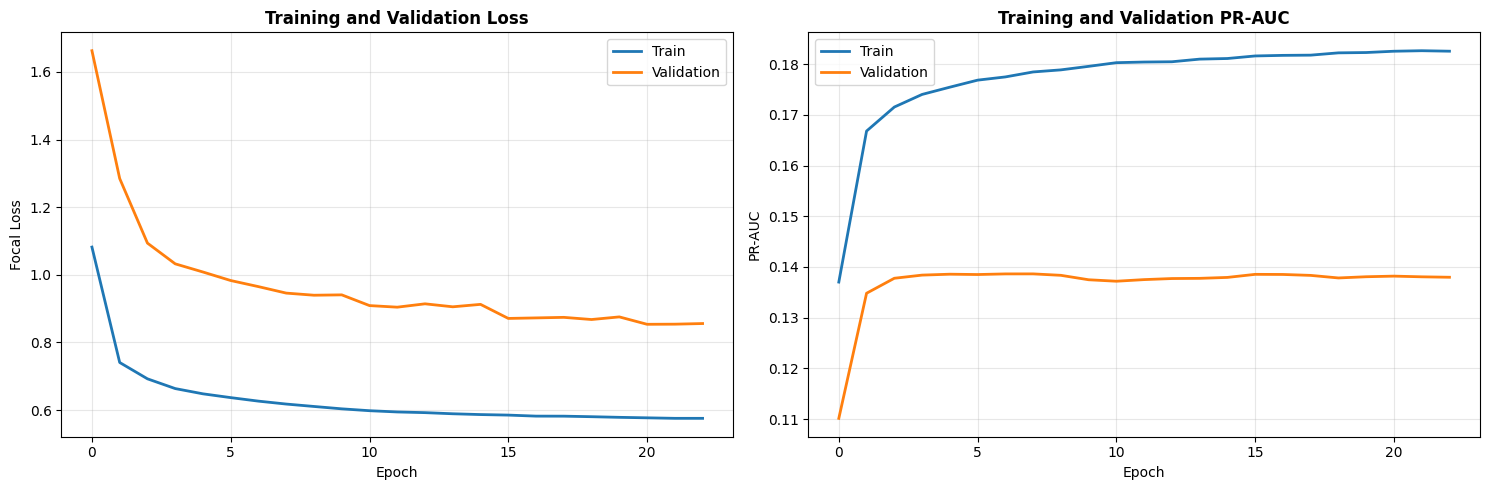

In [16]:
def plot_history(history):
    """Plot training loss and PR-AUC curves."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    axes[0].plot(history.history['loss'], label='Train', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Focal Loss')
    axes[0].set_title('Training and Validation Loss', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # PR-AUC (more informative than accuracy under heavy class imbalance)
    if 'aupr' in history.history:
        axes[1].plot(history.history['aupr'], label='Train', linewidth=2)
        axes[1].plot(history.history['val_aupr'], label='Validation', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('PR-AUC')
        axes[1].set_title('Training and Validation PR-AUC', fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('figures/cnn_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_history(history)

In [17]:
cnn.save('models_test/cnn_breakpoint_final.keras')
print("Model saved to models_test/cnn_breakpoint_final.keras")

Model saved to models_test/cnn_breakpoint_final.keras


## Breakpoint prediction evaluation

Three views of validation performance:

1. **Threshold sweep** with peak-based P / R / F1 to find the best operating point.
2. **Per-position ROC and PR curves** -- threshold-free quality.
3. **Visual inspection** of individual predictions with true breakpoints overlaid.

In [18]:
# Per-position breakpoint probabilities for every validation sample.
# Shape: (n_val, MAX_SEQ_LEN).
y_val_pred = cnn.predict(X_val, batch_size=BATCH_SIZE, verbose=1)

print(f"Prediction shape: {y_val_pred.shape}")
print(f"Range: [{y_val_pred.min():.4f}, {y_val_pred.max():.4f}]")

 1/39 ━━━━━━━━━━━━━━━━━━━━ 32s 850ms/step

 2/39 ━━━━━━━━━━━━━━━━━━━━ 9s 263ms/step 

 3/39 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step

 4/39 ━━━━━━━━━━━━━━━━━━━━ 8s 233ms/step

 5/39 ━━━━━━━━━━━━━━━━━━━━ 7s 235ms/step

...

37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step

38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step

39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 302ms/step


Prediction shape: (621, 10000)
Range: [0.0377, 0.9999]


In [19]:
# Evaluate at multiple thresholds to find the best operating point.
# Sweep extended through 0.95 from run #7 onward — predictions now span
# the full sigmoid range, so the val-best threshold can be much higher
# than the historical 0.3.
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
results = []

print(f"Peak-based evaluation (+/-{TOLERANCE} bp tolerance, "
      f"min peak separation = {TOLERANCE} bp)")
print("=" * 60)

for thr in thresholds:
    p, r, f = evaluate_peaks(y_val_pred, meta_val, TOLERANCE, thr)
    results.append({'threshold': thr, 'precision': p, 'recall': r, 'f1': f})
    print(f"  threshold={thr:.2f}  P={p:.3f}  R={r:.3f}  F1={f:.3f}")

results_df = pd.DataFrame(results)
best_idx = results_df['f1'].idxmax()
best_thr = results_df.loc[best_idx, 'threshold']
print(f"\nBest threshold: {best_thr} (F1={results_df.loc[best_idx, 'f1']:.3f})")


Peak-based evaluation (+/-200 bp tolerance, min peak separation = 200 bp)
  threshold=0.20  P=0.082  R=0.660  F1=0.142
  threshold=0.30  P=0.159  R=0.449  F1=0.213
  threshold=0.40  P=0.246  R=0.381  F1=0.263


  threshold=0.50  P=0.285  R=0.344  F1=0.281


  threshold=0.60  P=0.309  R=0.308  F1=0.281
  threshold=0.70  P=0.324  R=0.289  F1=0.282
  threshold=0.80  P=0.326  R=0.250  F1=0.266
  threshold=0.90  P=0.323  R=0.218  F1=0.249
  threshold=0.95  P=0.326  R=0.202  F1=0.242

Best threshold: 0.7 (F1=0.282)


### Per-sample prediction visualisation

Top panel: predicted probability over the genome with the threshold
line (red, dashed) and true breakpoint positions (green, vertical).
Bottom panel: ground-truth label mask.

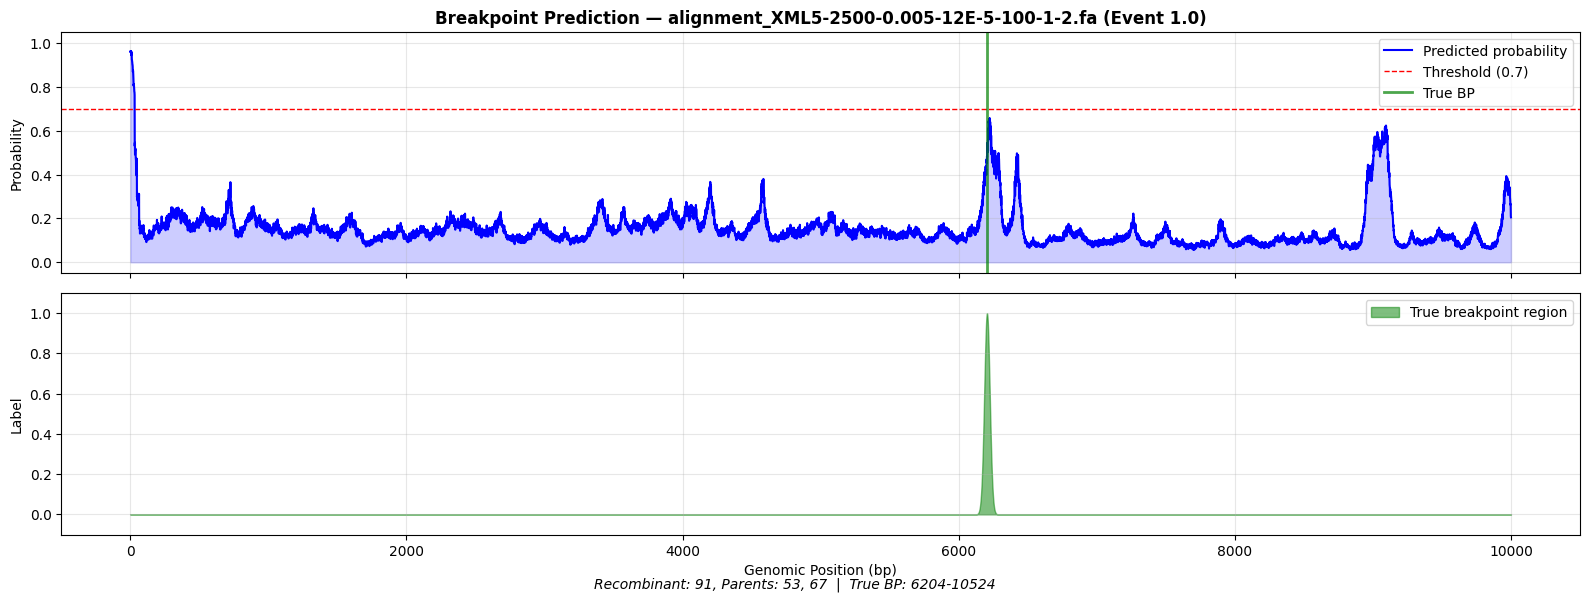

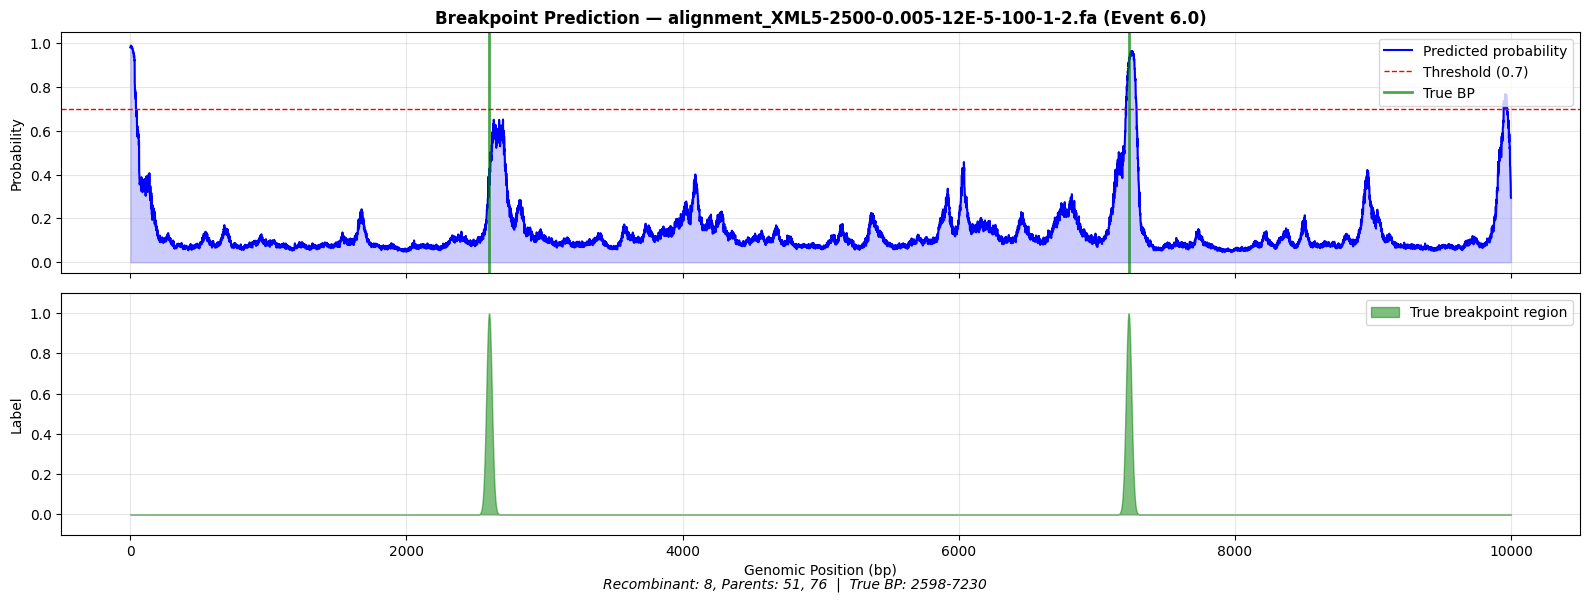

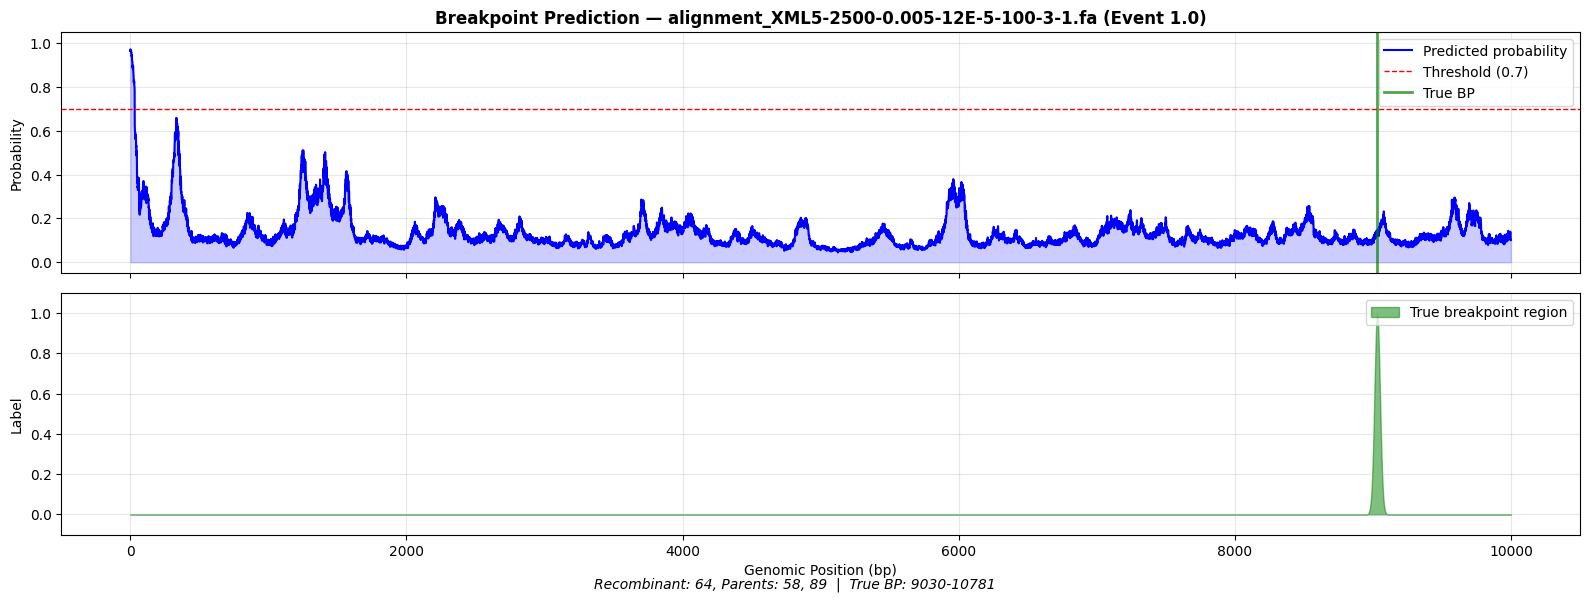

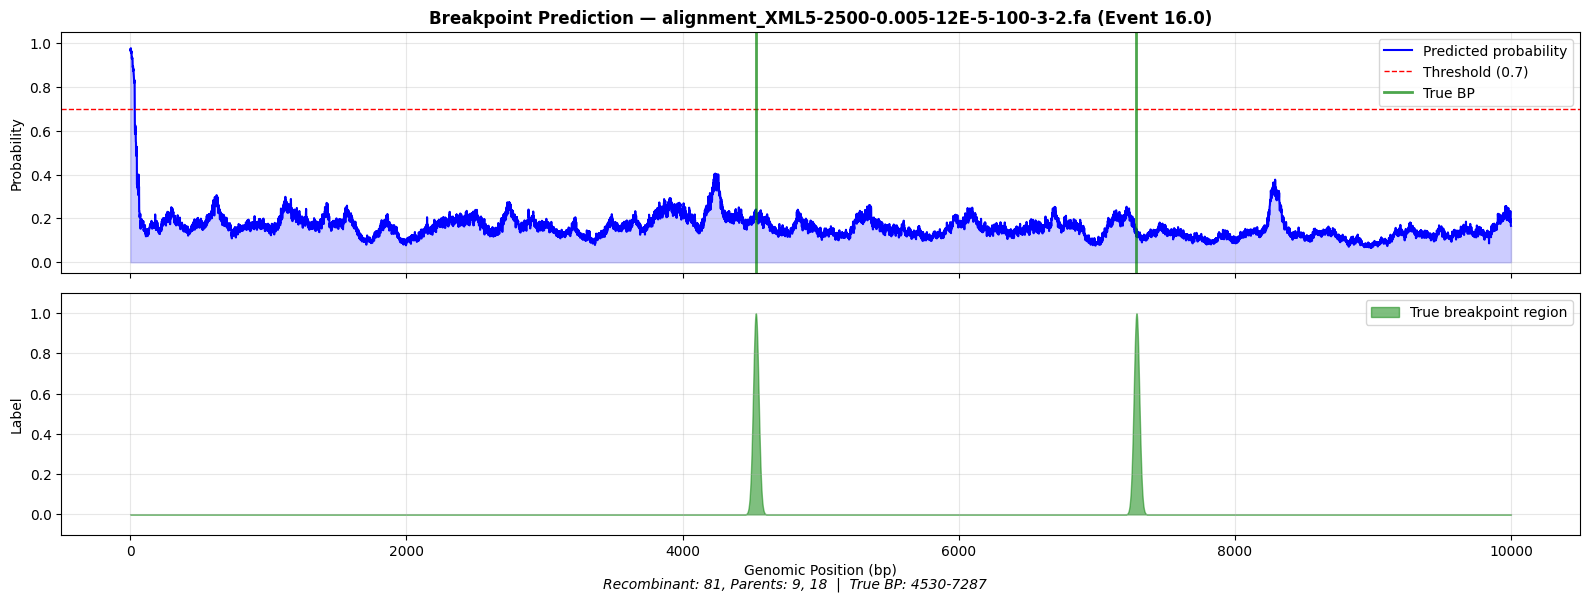

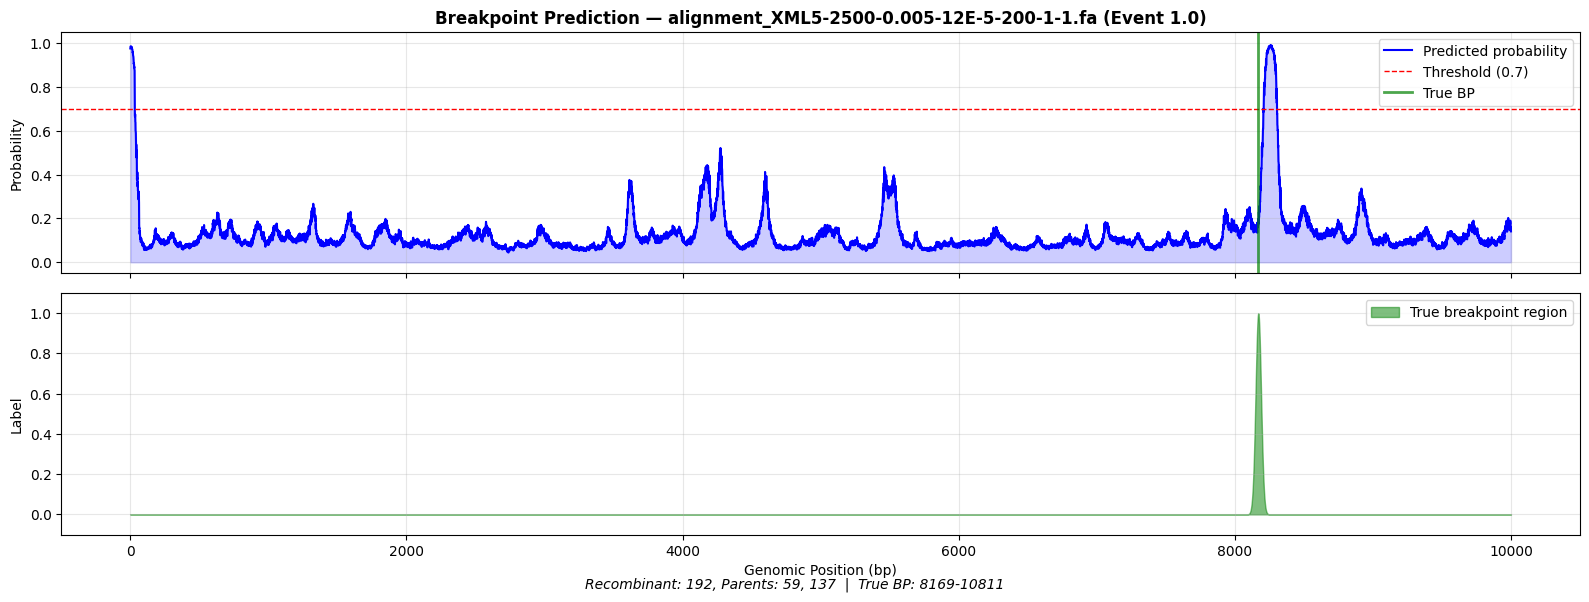

In [20]:
def plot_breakpoint_prediction(idx, X, y_true, y_pred, meta, threshold=0.5):
    """Visualise per-position breakpoint prediction for a single sample.

    Top panel: predicted probability with threshold line and true breakpoint markers.
    Bottom panel: ground truth label mask.
    """
    m = meta[idx]
    # Clamp to the prediction/label vector length: sequences longer than
    # MAX_SEQ_LEN were truncated at encoding time, so y_pred/y_true only
    # cover the first MAX_SEQ_LEN bp regardless of actual_len.
    L = min(m['actual_len'], y_pred.shape[1])
    positions = np.arange(L)

    yt = y_true[idx][:L]
    yp = y_pred[idx][:L]

    fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

    # Prediction curve
    axes[0].plot(positions, yp, color='blue', linewidth=1.5, label='Predicted probability')
    axes[0].axhline(threshold, color='red', linestyle='--', linewidth=1,
                    label=f'Threshold ({threshold})')
    axes[0].fill_between(positions, 0, yp, alpha=0.2, color='blue')

    # Mark true breakpoints
    for bp in [m['bp_start'], m['bp_end']]:
        if bp < L:
            axes[0].axvline(bp, color='green', linewidth=2, alpha=0.7, label='True BP')

    axes[0].set_ylabel('Probability')
    axes[0].set_title(
        f'Breakpoint Prediction \u2014 {m["file"]} (Event {m["event"]})',
        fontweight='bold'
    )
    # Deduplicate legend entries
    handles, lbls = axes[0].get_legend_handles_labels()
    by_label = dict(zip(lbls, handles))
    axes[0].legend(by_label.values(), by_label.keys(), loc='upper right')
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].grid(True, alpha=0.3)

    # Ground truth
    axes[1].fill_between(positions, 0, yt, color='green', alpha=0.5,
                         label='True breakpoint region')
    axes[1].set_xlabel('Genomic Position (bp)')
    axes[1].set_ylabel('Label')
    axes[1].set_ylim(-0.1, 1.1)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    info = (f"Recombinant: {m['recomb_id']}, "
            f"Parents: {m['parent1_id']}, {m['parent2_id']}  |  "
            f"True BP: {m['bp_start']}-{m['bp_end']}")
    fig.text(0.5, 0.01, info, ha='center', fontsize=10, style='italic')

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    return fig


# Plot example predictions
for i in range(min(5, len(X_val))):
    fig = plot_breakpoint_prediction(i, X_val, y_val, y_val_pred, meta_val,
                                    threshold=best_thr)
    fig.savefig(f'figures/bp_prediction_val_{i}.png', dpi=150, bbox_inches='tight')
    plt.show()

### ROC and precision-recall curves

Computed at the per-position level (every position, all samples flattened).
PR-AUC is the more honest summary because of the class imbalance --
ROC-AUC can look great while the model still misses most breakpoints.

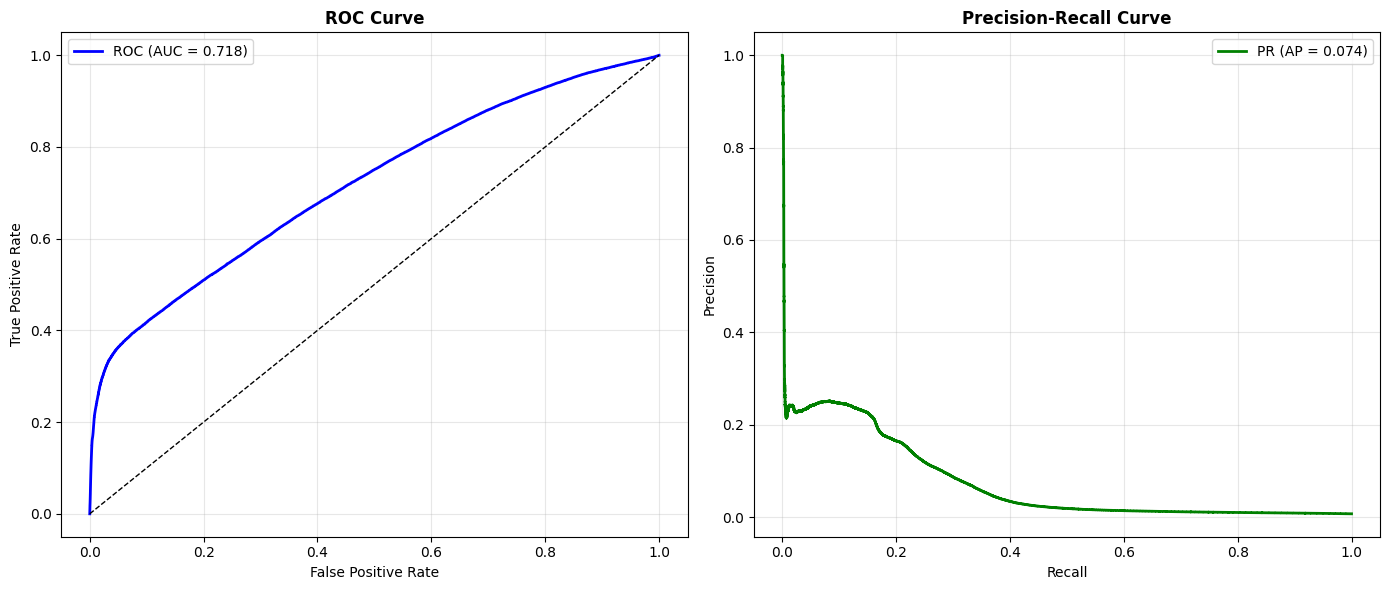

In [21]:
def plot_roc_and_pr(y_true_flat, y_pred_flat):
    """Plot ROC and Precision-Recall curves for per-position predictions."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ROC
    fpr, tpr, _ = roc_curve(y_true_flat, y_pred_flat)
    roc_auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc_val:.3f})')
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_true_flat, y_pred_flat)
    ap = average_precision_score(y_true_flat, y_pred_flat)
    axes[1].plot(rec, prec, 'g-', linewidth=2, label=f'PR (AP = {ap:.3f})')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('figures/cnn_roc_pr_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


# Binarize soft Gaussian targets for ROC/PR (>= 0.5 captures positions
# within ~1.18*sigma of a breakpoint).
y_val_binary = (y_val >= 0.5).astype(np.int8)
plot_roc_and_pr(y_val_binary.flatten(), y_val_pred.flatten())

### Per-sample performance distribution

How does performance vary across samples? Histograms of per-sample
precision, recall, and F1 reveal whether average numbers come from
consistently decent predictions or a small number of perfect predictions
mixed with many failures.

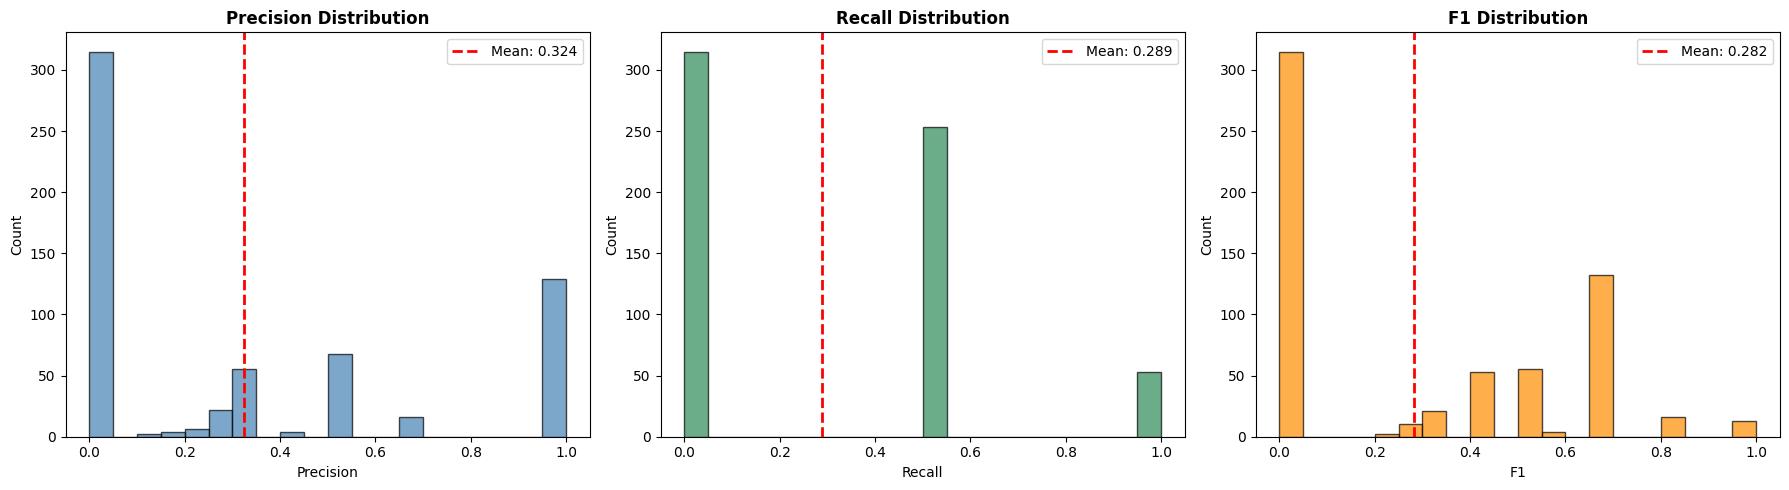


Per-sample performance summary:
       precision   recall       f1  n_peaks  n_matched
count    621.000  621.000  621.000  621.000    621.000
mean       0.324    0.289    0.282    1.847      0.578
std        0.394    0.322    0.309    1.242      0.644
min        0.000    0.000    0.000    1.000      0.000
25%        0.000    0.000    0.000    1.000      0.000
50%        0.000    0.000    0.000    1.000      0.000
75%        0.500    0.500    0.667    3.000      1.000
max        1.000    1.000    1.000    8.000      2.000


In [22]:
# Per-sample metric distributions
sample_metrics = []
for i in range(len(y_val)):
    true_bps = [meta_val[i]['bp_start'], meta_val[i]['bp_end']]
    p, r, f, n_peaks, n_matched = peak_metrics_single(
        true_bps, y_val_pred[i], TOLERANCE, best_thr,
    )
    sample_metrics.append({
        'precision': p, 'recall': r, 'f1': f,
        'n_peaks': n_peaks, 'n_matched': n_matched,
    })

metrics_df = pd.DataFrame(sample_metrics)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, colour in zip(axes, ['precision', 'recall', 'f1'],
                            ['steelblue', 'seagreen', 'darkorange']):
    ax.hist(metrics_df[col], bins=20, color=colour, alpha=0.7, edgecolor='black')
    mean_val = metrics_df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
               label=f'Mean: {mean_val:.3f}')
    ax.set_xlabel(col.title())
    ax.set_ylabel('Count')
    ax.set_title(f'{col.title()} Distribution', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('figures/cnn_metric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-sample performance summary:")
print(metrics_df.describe().round(3))

### Event-level detection summary

Per-position metrics tell us how sharp the predictions are; this section
answers the more practical question: **how many recombination events did
the model actually find?**

Each event has two true breakpoints (`bp_start`, `bp_end`). Using the
best threshold and the existing greedy nearest-first matching within
`+/-TOLERANCE` bp, every event is classified as:

- **both**   -- both breakpoints matched to a predicted peak
- **one**    -- exactly one breakpoint matched (partial detection)
- **missed** -- neither breakpoint matched

We also report per-BP localisation error (|predicted - true| in bp) and
breakdowns by genome length and topology so it is clear *where* the
model is failing rather than just an averaged number.


In [23]:
def classify_event(true_bps, y_pred, tolerance=TOLERANCE,
                   threshold=0.5, min_distance=None):
    """Per-event detection summary.

    Uses the same peak detection and greedy nearest-first matching as
    `peak_metrics_single`, but reports event-level outcomes (both / one /
    missed) plus per-true-BP localisation error.

    Returns:
        dict with keys:
            status        -- "both" | "one" | "missed"
            n_matched     -- number of true BPs matched (0, 1, or 2)
            bp_distances  -- list of |pred - true| in bp per true BP
                             (np.nan if that true BP was unmatched)
            n_peaks       -- total predicted peaks
            n_extra       -- predicted peaks not matching any true BP
    """
    if min_distance is None:
        min_distance = tolerance

    peaks = detect_peaks(y_pred, threshold=threshold, min_distance=min_distance)
    true_bps = list(true_bps)

    pairs = sorted(
        ((abs(int(p) - int(t)), pi, ti)
         for pi, p in enumerate(peaks)
         for ti, t in enumerate(true_bps)),
        key=lambda x: x[0],
    )
    matched_pred, matched_true = set(), set()
    distances = [np.nan] * len(true_bps)
    for d, pi, ti in pairs:
        if d > tolerance:
            break
        if pi in matched_pred or ti in matched_true:
            continue
        matched_pred.add(pi)
        matched_true.add(ti)
        distances[ti] = int(d)

    n_matched = len(matched_true)
    if n_matched == len(true_bps):
        status = "both"
    elif n_matched >= 1:
        status = "one"
    else:
        status = "missed"

    return {
        "status": status,
        "n_matched": n_matched,
        "bp_distances": distances,
        "n_peaks": len(peaks),
        "n_extra": len(peaks) - n_matched,
    }


def build_event_df(y_pred_batch, meta_batch, threshold, tolerance=TOLERANCE):
    """Build a per-event DataFrame of detection outcomes."""
    rows = []
    for yp, m in zip(y_pred_batch, meta_batch):
        info = classify_event(
            [m["bp_start"], m["bp_end"]], yp,
            tolerance=tolerance, threshold=threshold,
        )
        rows.append({
            "file": m["file"],
            "event": m["event"],
            "actual_len": m["actual_len"],
            "circular": m["bp_start"] > m["bp_end"],
            "status": info["status"],
            "n_matched": info["n_matched"],
            "d_start": info["bp_distances"][0],
            "d_end":   info["bp_distances"][1],
            "n_peaks": info["n_peaks"],
            "n_extra": info["n_extra"],
        })
    return pd.DataFrame(rows)


def print_event_summary(events_df, title):
    """Headline counts and percentages for an event DataFrame."""
    n_total = len(events_df)
    n_both   = int((events_df["status"] == "both").sum())
    n_one    = int((events_df["status"] == "one").sum())
    n_missed = int((events_df["status"] == "missed").sum())

    print("=" * 60)
    print(title)
    print("=" * 60)
    print(f"Total events:            {n_total}")
    print(f"Both BPs found:          {n_both:4d}  ({n_both/n_total:.1%})")
    print(f"One BP found (partial):  {n_one:4d}  ({n_one/n_total:.1%})")
    print(f"Missed entirely:         {n_missed:4d}  ({n_missed/n_total:.1%})")
    print(f"Any BP found (>=1):      {n_both + n_one:4d}  "
          f"({(n_both + n_one)/n_total:.1%})")
    print()
    print(f"Mean predicted peaks per event:  {events_df['n_peaks'].mean():.2f}")
    print(f"Mean false-positive peaks:       {events_df['n_extra'].mean():.2f}")


In [24]:
# Event-level analysis on the validation set
events_val = build_event_df(y_val_pred, meta_val, threshold=best_thr)
print_event_summary(
    events_val,
    f"EVENT-LEVEL DETECTION (validation, threshold={best_thr}, "
    f"tolerance=+/-{TOLERANCE} bp)",
)


EVENT-LEVEL DETECTION (validation, threshold=0.7, tolerance=+/-200 bp)
Total events:            621
Both BPs found:            53  (8.5%)
One BP found (partial):   253  (40.7%)
Missed entirely:          315  (50.7%)
Any BP found (>=1):       306  (49.3%)

Mean predicted peaks per event:  1.85
Mean false-positive peaks:       1.27


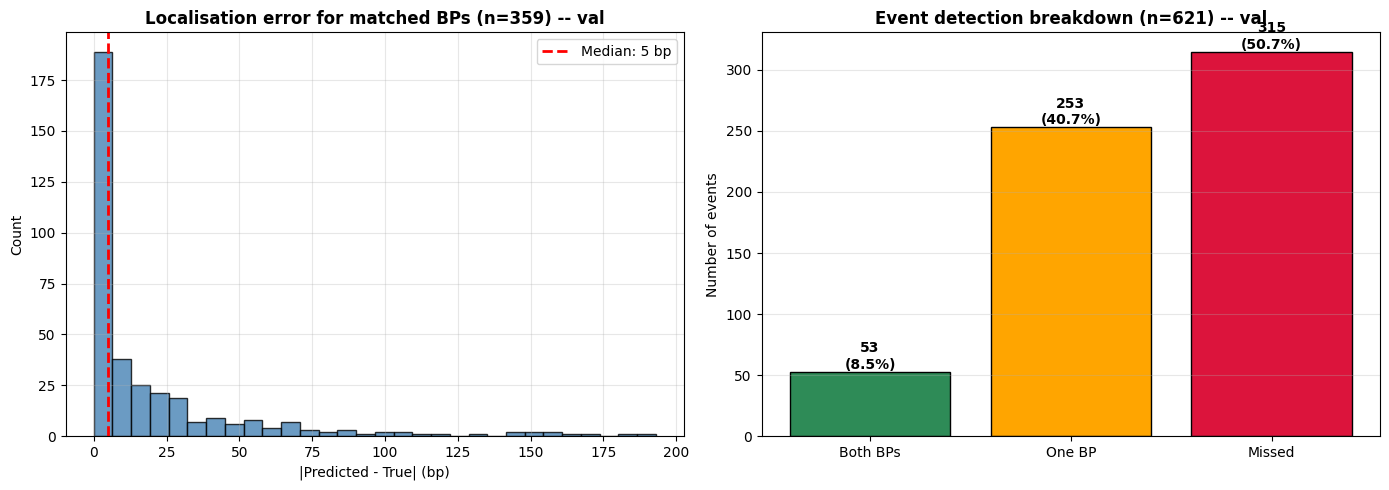

In [25]:
# Visual: localisation error histogram + status breakdown
def plot_event_summary(events_df, title_suffix=""):
    all_d = pd.concat([events_df["d_start"], events_df["d_end"]]).dropna()
    n_total = len(events_df)
    status_counts = (events_df["status"]
                     .value_counts()
                     .reindex(["both", "one", "missed"], fill_value=0))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if len(all_d) > 0:
        axes[0].hist(all_d, bins=30, color="steelblue",
                     alpha=0.8, edgecolor="black")
        axes[0].axvline(all_d.median(), color="red", linestyle="--",
                        linewidth=2, label=f"Median: {all_d.median():.0f} bp")
        axes[0].legend()
    axes[0].set_xlabel("|Predicted - True| (bp)")
    axes[0].set_ylabel("Count")
    axes[0].set_title(
        f"Localisation error for matched BPs (n={len(all_d)}){title_suffix}",
        fontweight="bold",
    )
    axes[0].grid(True, alpha=0.3)

    bars = axes[1].bar(
        ["Both BPs", "One BP", "Missed"], status_counts.values,
        color=["seagreen", "orange", "crimson"], edgecolor="black",
    )
    for bar, v in zip(bars, status_counts.values):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2, v,
            f"{v}\n({v/n_total:.1%})" if n_total else f"{v}",
            ha="center", va="bottom", fontweight="bold",
        )
    axes[1].set_ylabel("Number of events")
    axes[1].set_title(
        f"Event detection breakdown (n={n_total}){title_suffix}",
        fontweight="bold",
    )
    axes[1].grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    return fig


fig = plot_event_summary(events_val, title_suffix=" -- val")
fig.savefig("figures/event_detection_val.png", dpi=150, bbox_inches="tight")
plt.show()


In [26]:
# Detection breakdown by genome length and topology (validation)
def detection_breakdown(events_df, group_col, group_label_map=None):
    """Cross-tab of status counts plus a both_pct column for quick reading."""
    tab = (events_df
           .groupby(group_col, observed=True)["status"]
           .value_counts()
           .unstack(fill_value=0)
           .reindex(columns=["both", "one", "missed"], fill_value=0))
    tab["total"] = tab.sum(axis=1)
    tab["both_pct"] = (tab["both"] / tab["total"] * 100).round(1)
    tab["any_pct"]  = ((tab["both"] + tab["one"]) / tab["total"] * 100).round(1)
    if group_label_map:
        tab.index = tab.index.map(lambda v: group_label_map.get(v, v))
    return tab


events_val = events_val.assign(
    len_bin=pd.cut(
        events_val["actual_len"],
        bins=[0, 2000, 3000, 4000, np.inf],
        labels=["<2kb", "2-3kb", "3-4kb", ">=4kb"],
    ),
)

print("Detection by genome length (validation):")
print(detection_breakdown(events_val, "len_bin"))
print()
print("Detection by genome topology (validation):")
print(detection_breakdown(events_val, "circular",
                          group_label_map={False: "Linear", True: "Circular"}))


Detection by genome length (validation):
status   both  one  missed  total  both_pct  any_pct
len_bin                                             
>=4kb      53  253     315    621       8.5     49.3

Detection by genome topology (validation):
status    both  one  missed  total  both_pct  any_pct
circular                                             
Linear      53  253     315    621       8.5     49.3


## Unseen test set evaluation

`UnseenTestSet/` was never touched during training or threshold tuning.
We re-use the best threshold found on validation and report peak-based
P / R / F1 against held-out simulations.

In [27]:
# Load and evaluate on unseen test set. mask_test is unused for predict
# but kept for symmetry with the training load — useful if we later run
# a masked metric on this set.
X_test, y_test, mask_test, meta_test = load_dataset(
    [TEST_DIR],
    label_mode='breakpoint',
)

y_test_pred = cnn.predict(X_test, batch_size=BATCH_SIZE, verbose=1)

p, r, f = evaluate_peaks(y_test_pred, meta_test, TOLERANCE, best_thr)

print("\n" + "=" * 60)
print("UNSEEN TEST SET PERFORMANCE (peak-based)")
print("=" * 60)
print(f"Precision: {p:.3f}")
print(f"Recall:    {r:.3f}")
print(f"F1 Score:  {f:.3f}")
print(f"Threshold: {best_thr}  |  Tolerance: +/-{TOLERANCE} bp")
print("=" * 60)



Processing UnseenTestSet: 97 files


UnseenTestSet:   0%|          | 0/97 [00:00<?, ?it/s]

UnseenTestSet:   6%|▌         | 6/97 [00:00<00:01, 49.73it/s]

UnseenTestSet:  12%|█▏        | 12/97 [00:00<00:01, 51.30it/s]

UnseenTestSet:  19%|█▊        | 18/97 [00:00<00:01, 47.83it/s]

...

4/6 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step



UNSEEN TEST SET PERFORMANCE (peak-based)
Precision: 0.205
Recall:    0.177
F1 Score:  0.172
Threshold: 0.7  |  Tolerance: +/-200 bp


EVENT-LEVEL DETECTION (test, threshold=0.7, tolerance=+/-200 bp)
Total events:            82
Both BPs found:             3  (3.7%)
One BP found (partial):    23  (28.0%)
Missed entirely:           56  (68.3%)
Any BP found (>=1):        26  (31.7%)

Mean predicted peaks per event:  2.34
Mean false-positive peaks:       1.99


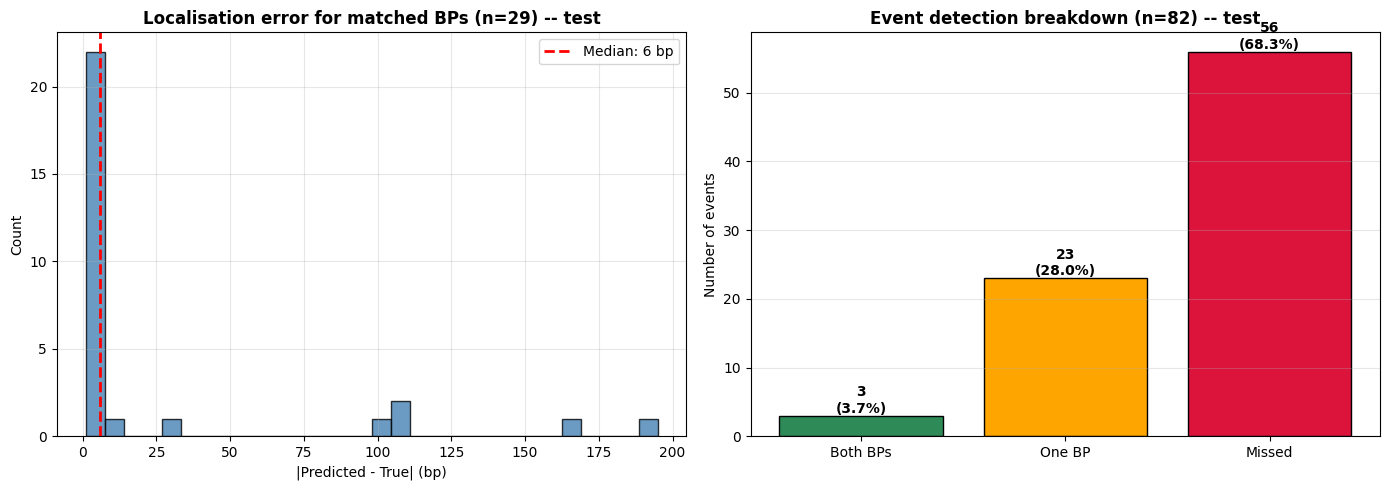

In [28]:
# Event-level summary on the unseen test set
events_test = build_event_df(y_test_pred, meta_test, threshold=best_thr)
print_event_summary(
    events_test,
    f"EVENT-LEVEL DETECTION (test, threshold={best_thr}, "
    f"tolerance=+/-{TOLERANCE} bp)",
)

fig = plot_event_summary(events_test, title_suffix=" -- test")
fig.savefig("figures/event_detection_test.png", dpi=150, bbox_inches="tight")
plt.show()


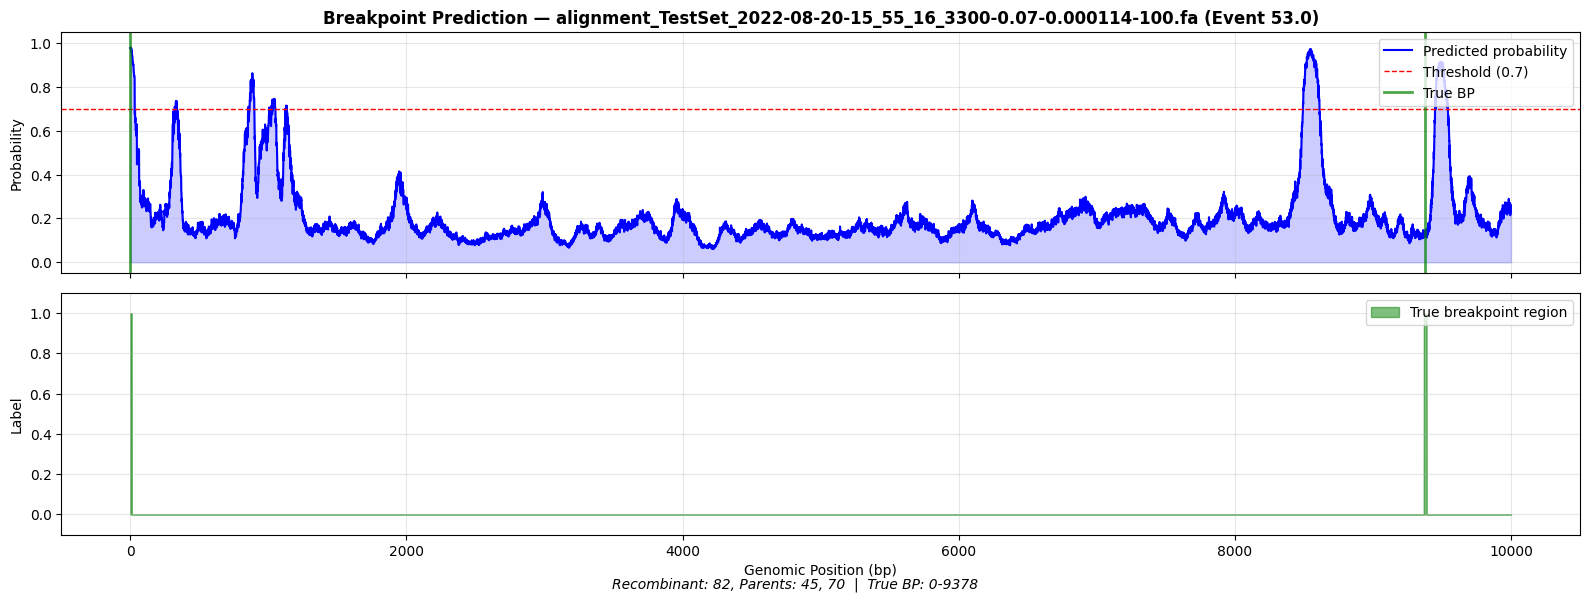

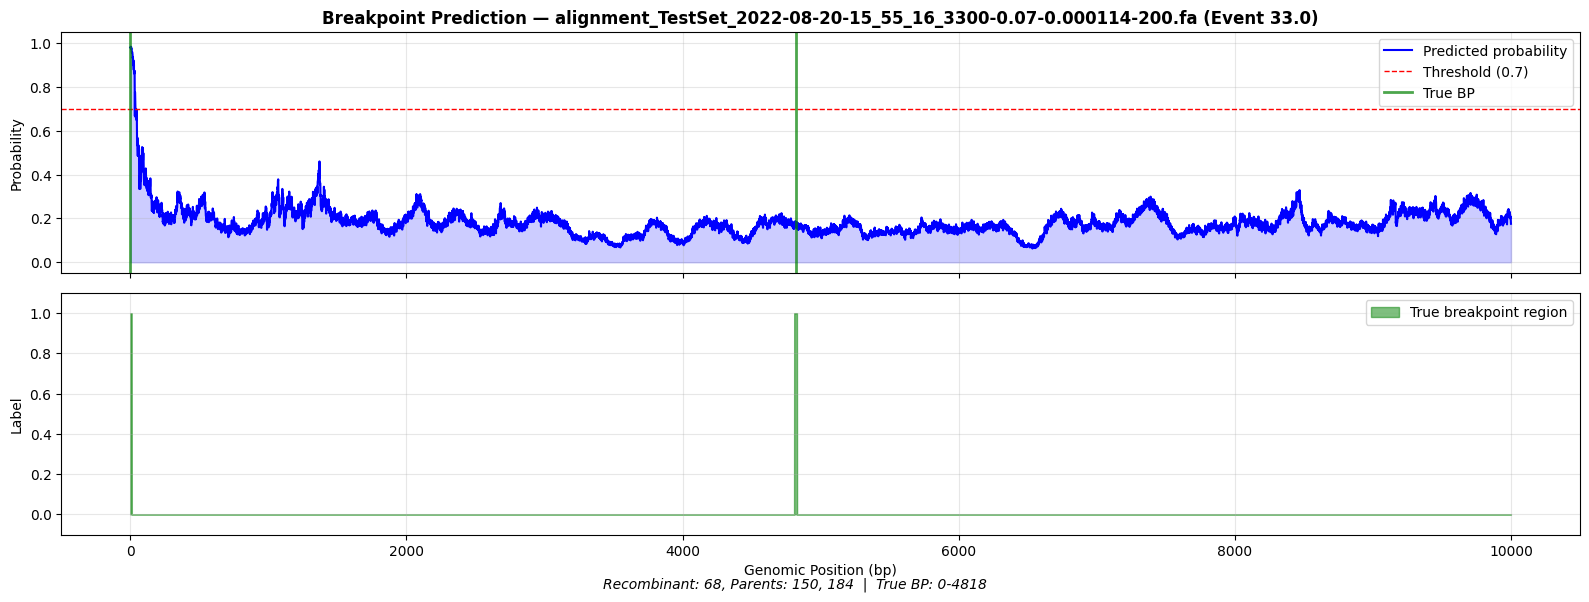

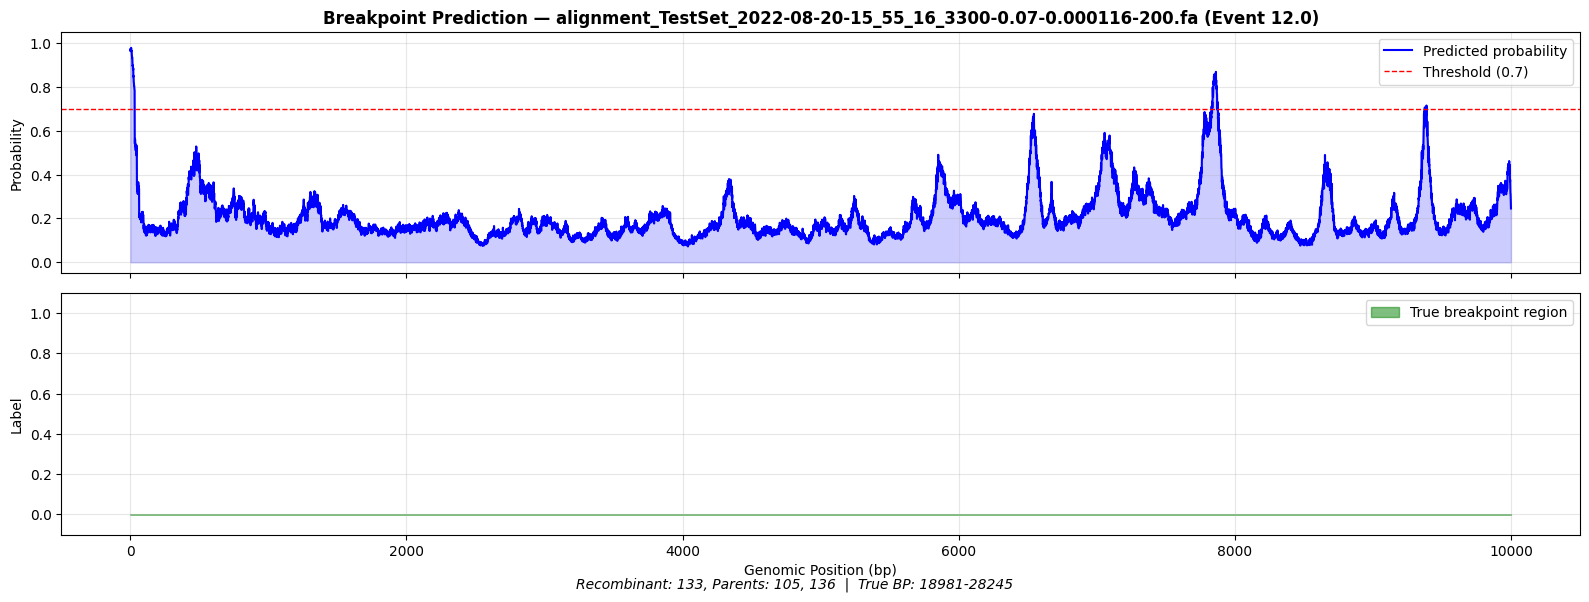

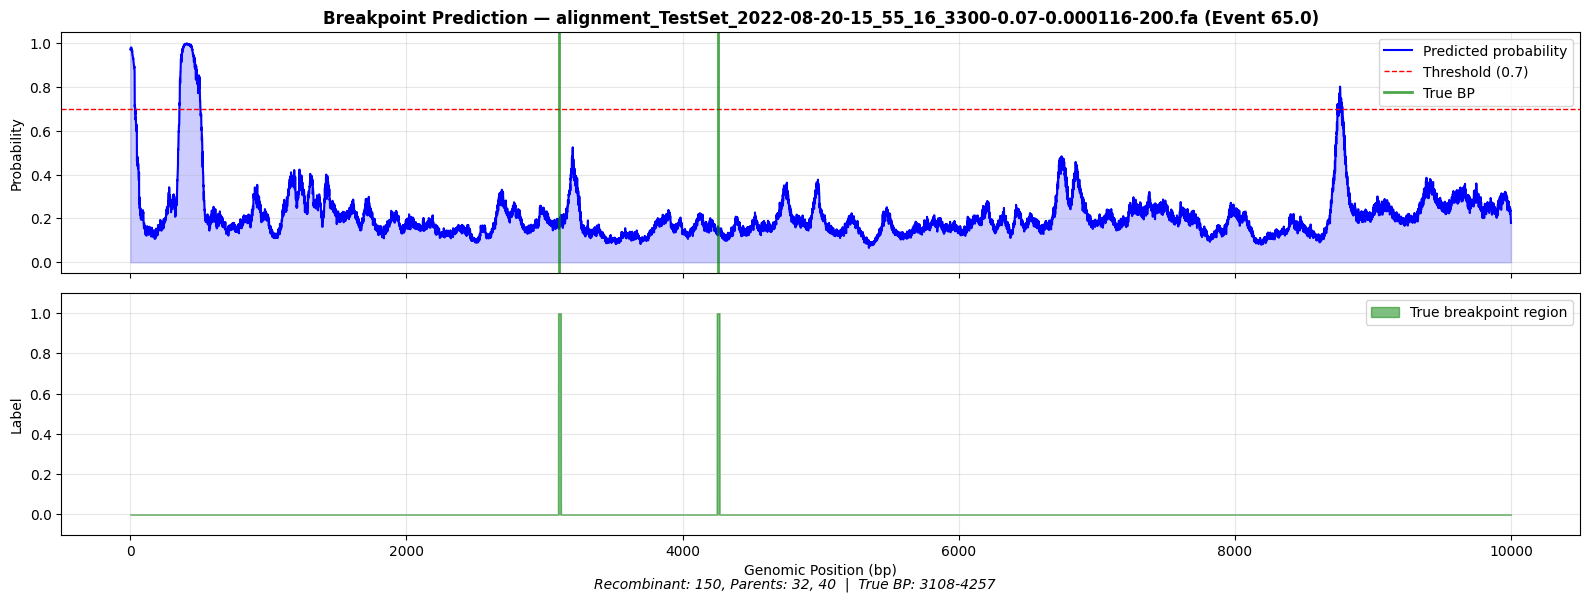

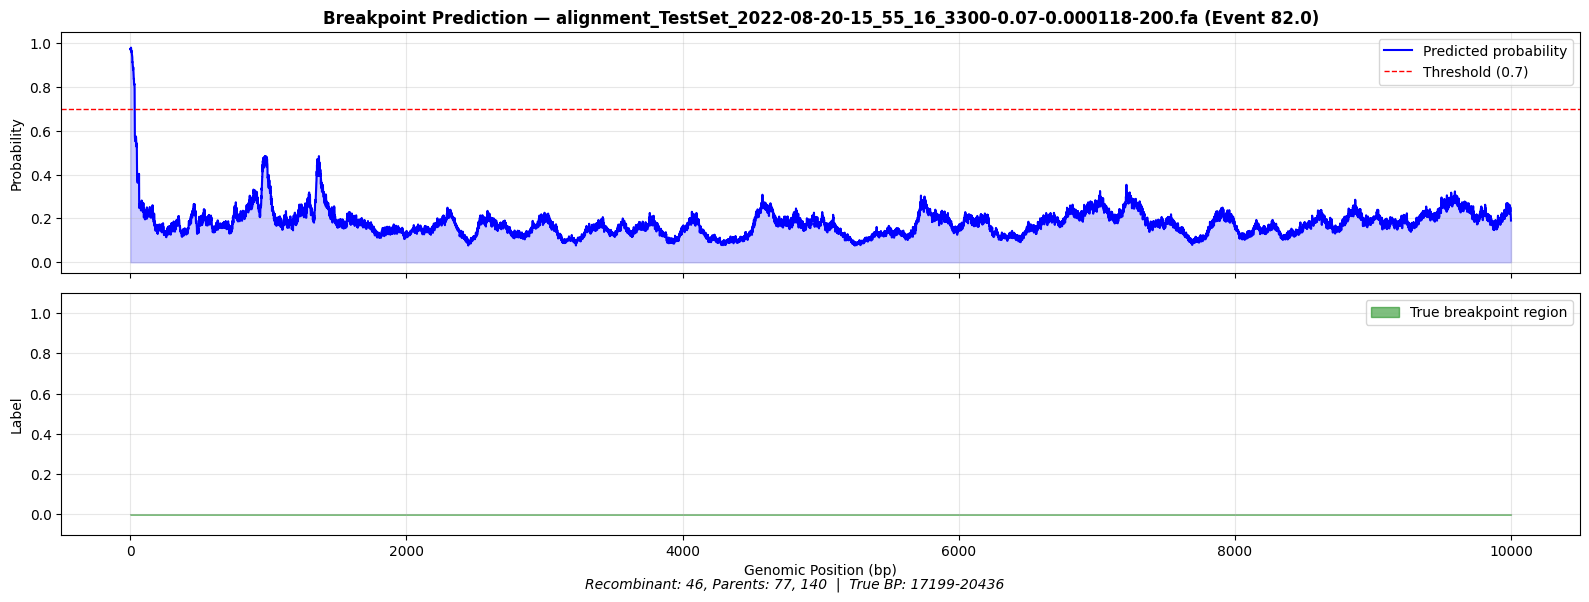

In [29]:
# Visualise test set predictions
for i in range(min(5, len(X_test))):
    fig = plot_breakpoint_prediction(i, X_test, y_test, y_test_pred,
                                    meta_test, threshold=best_thr)
    fig.savefig(f'figures/bp_prediction_test_{i}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Analysis

Performance breakdowns and interpretability:

- **Circular vs linear breakpoints** -- does the model handle wrap-around correctly?
- **Performance by genome length** -- does padding longer or shorter sequences hurt?
- **Saliency maps** -- which input positions does the model attend to?

In [30]:
# Circular vs linear genome breakpoints
circular_mask = np.array([m['bp_start'] > m['bp_end'] for m in meta_val])

if circular_mask.any():
    circ_metrics = metrics_df[circular_mask]
    lin_metrics = metrics_df[~circular_mask]

    print("Performance comparison: Circular vs Linear genomes")
    print("\nCircular:")
    print(circ_metrics[['precision', 'recall', 'f1']].describe().round(3))
    print("\nLinear:")
    print(lin_metrics[['precision', 'recall', 'f1']].describe().round(3))
else:
    print("No circular genome breakpoints found in validation set.")

No circular genome breakpoints found in validation set.


In [31]:
# Performance by genome length
metrics_df['actual_len'] = [m['actual_len'] for m in meta_val]

# Bins extended to cover the full ~10kb range now that MAX_SEQ_LEN=10000.
bins = [0, 2500, 3000, 3500, 4500, 6000, 8000, 10500]
bin_labels = ['<2500', '2500-3000', '3000-3500', '3500-4500', '4500-6000',
              '6000-8000', '8000+']
metrics_df['len_bin'] = pd.cut(metrics_df['actual_len'], bins=bins, labels=bin_labels)

length_perf = metrics_df.groupby('len_bin', observed=True)[['precision', 'recall', 'f1']].agg(
    ['mean', 'std', 'count']
)
print("Performance by genome length:")
print(length_perf.round(3))

# Plot — guard against single-bin val sets (e.g. held-out XML-5).
summary = metrics_df.groupby('len_bin', observed=True)['f1'].agg(['mean', 'std'])
if len(summary) >= 1 and len(summary) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    try:
        summary.plot(y='mean', yerr='std', kind='bar', ax=ax, capsize=5,
                     color='steelblue', edgecolor='black', legend=False)
        ax.set_xlabel('Genome Length Bin')
        ax.set_ylabel('Mean F1 Score')
        ax.set_title('Model Performance by Genome Length', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig('figures/performance_by_length.png', dpi=150, bbox_inches='tight')
        plt.show()
    except (IndexError, ValueError) as e:
        print(f"Skipping length-bin plot ({e}) — likely too few populated bins.")
        plt.close()


Performance by genome length:
Empty DataFrame
Columns: [(precision, mean), (precision, std), (precision, count), (recall, mean), (recall, std), (recall, count), (f1, mean), (f1, std), (f1, count)]
Index: []


### Saliency map (input attribution)

Gradient of the model output with respect to the input shows which
positions most strongly drive the prediction. Currently averaged over
all output positions; for a sharper picture see TODO.md (compute
saliency w.r.t. specific high-probability peaks instead).

In [ ]:
@tf.function
def compute_saliency(model, x):
    """Gradient-based saliency map for input attribution.

    Currently averages over all output positions (`reduce_mean(pred)`),
    which gives a smeared "average importance" map. For sharper
    attribution at a specific breakpoint, replace with a sum over
    the indices of the predicted peaks -- see TODO.md.
    """
    with tf.GradientTape() as tape:
        tape.watch(x)
        pred = model(x)
        target = tf.reduce_mean(pred)
    return tape.gradient(target, x)


sample_idx = 0
sample_in = tf.convert_to_tensor(X_val[sample_idx:sample_idx + 1], dtype=tf.float32)
saliency = compute_saliency(cnn, sample_in)
# |grad| summed over channels -> scalar importance per genomic position
saliency_per_pos = np.abs(saliency.numpy()[0]).sum(axis=1)

m = meta_val[sample_idx]
L = min(m['actual_len'], y_val_pred.shape[1])  # clamp to prediction length

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(range(L), saliency_per_pos[:L], color='purple', linewidth=1)
for bp in [m['bp_start'], m['bp_end']]:
    if bp < L:
        axes[0].axvline(bp, color='red', linestyle='--', alpha=0.7)
axes[0].set_ylabel('|Gradient| (summed over channels)')
axes[0].set_title('Saliency Map — Feature Importance per Position', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(L), y_val_pred[sample_idx][:L], 'b-', label='Prediction', linewidth=1.5)
axes[1].fill_between(range(L), 0, y_val[sample_idx][:L],
                     color='green', alpha=0.3, label='Ground Truth')
axes[1].set_xlabel('Genomic Position (bp)')
axes[1].set_ylabel('Probability')
axes[1].set_title('Prediction vs Ground Truth', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/saliency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Experiment Log

This is the canonical record of every training run. New entries go at the **top**.
See [HANDOVER.md](HANDOVER.md) §5 for the entry template and §6 for the
KEPT / REVERTED / INCONCLUSIVE decision criteria.

If you change the metric set, add a new field at the bottom of the template — do not redefine existing ones.

---

## Pending: Run #17 — extended MaxChi windows {50, 100, 200, 500, 1000, 2000}

cell-3 has been edited to bump `N_MAXCHI_WINDOWS` from 4 → 6 and add
windows 1000 and 2000 to `MAXCHI_WINDOWS`. Total `N_INPUT_CHANNELS = 24`.
The run was started before the machine migration but killed mid-data-prep
(no epoch completed). **The next agent should run this first** — see
HANDOVER.md §12.

The cached `models_test/cnn_breakpoint_best.keras` is run #16's model
(dropout=0.5, 4 MaxChi windows). The notebook's cell-22 outputs are also
still from run #16. The *only* thing changed for #17 is cell-3.

After running, append the actual run #17 entry above this placeholder.

---

## 2026-05-04 #16 — Increase dropout 0.3 → 0.5

**Hypothesis:** Run #15 exposed a +0.072 train-val PR-AUC gap (overfitting to XML-1..4). Bumping dropout 0.3 → 0.5 in `build_cnn` is the cheapest test of whether reducing model capacity at training time closes the gap and improves generalization to held-out XML-5 / UnseenTestSet.

**Change:** cell-18: `dropout=0.3` → `dropout=0.5` in the `build_cnn` default. Single-axis change.

**Config snapshot:**
- max_files: None (3331 train / 621 val from XML-5 held-out)
- LABEL_SIGMA: 20
- POS_WEIGHT: 70.0
- MAX_SEQ_LEN: 10000
- N_INPUT_CHANNELS: 22 (with MaxChi from #13)
- dropout: 0.5

**Results (at val-best threshold = 0.7):**
- Best epoch: 8 (val_aupr peaked very early — model under-fits at this dropout)
- Train PR-AUC at best epoch: ~0.176 (vs ~0.215 in #15 — DOWN, regularization is biting)
- Val PR-AUC at best epoch: 0.139 (vs 0.143 in #15 — basically flat)
- Train-val PR-AUC gap: +0.037 (vs +0.072 in #15 — narrowed by half but not closed)
- Val F1 (peak-based): 0.282 (vs 0.321 in #15 — −0.039)
- Val "Both BPs found": 8.5% (vs 18.2% in #15 — **−9.7pp**, capability halved)
- Test F1 (peak-based): **0.172** (vs 0.151 in #15 — **+0.021**, clears KEPT bar)
- Test "Both BPs found": 3.7% (vs 4.9% in #15 — −1.2pp)
- Test precision / recall: 0.205 / 0.177 (vs 0.135 / 0.213 — precision +0.070, recall −0.036)
- Mean predicted peaks / event: 2.34 (test); 1.85 (val)

**Verdict:** KEPT (Test F1 +0.021 ≥ +0.01 under §6 criterion 1)

**Why:** Mixed signal — the strongest test F1 improvement in many runs (+0.021), but val Both BPs halved (18.2% → 8.5%). Higher dropout pushed the model into a precision regime: it emits ~2 peaks per genome instead of 4, with higher per-peak confidence but missing more total BPs. The trade-off looks similar to run #10 (LayerNorm) but less severe — Both BPs didn't collapse to 0%, and test F1 actually moved.

The train-val gap narrowed from +0.072 to +0.037 (~50% reduction), so dropout did partially address overfitting — but not enough to lift val. The gain shows up only on test, suggesting test/val mismatch is more about distribution than overfitting.

**Side observations:**
- Best epoch=8 (vs 16 in #15, 14 in #14, 13 in #13) — the model finds its best very early and then drifts. Could be EarlyStopping triggering on noise, or genuine quick convergence under stronger regularization.
- Dropout 0.5 may be too aggressive. A sweet spot at 0.4 is worth trying — but stack one experiment at a time.

**Next:** Run #17 — extend MaxChi windows from {50, 100, 200, 500} to {50, 100, 200, 500, 1000, 2000}. The ≥4kb val regime (XML-5 is entirely ≥4kb) and the test set (also long) should benefit from wider parental-disparity statistics. N_INPUT_CHANNELS bumps 22 → 24. Single change — same input-channels-driven leverage that delivered #13's gains, applied at longer scales now that the long-genome regime is the primary signal source.

---

## 2026-05-04 #15 — Strict held-out split: TRAIN=XML-1..4, VAL=XML-5

**Hypothesis:** Run #14's val gain (+0.015 F1, +5.5pp Both BPs) didn't transfer to test, suggesting the previous mixed-XML val was sharing distribution with training. A strict directory-level held-out (XML-5 entirely as val) tests cross-configuration generalization — closer to the simulation→real transfer the project ultimately wants. This is a *diagnostic* run; the goal is to recalibrate what "good" means, not to lift headline numbers.

**Change:** cell-12: load XML-1..4 and XML-5 as separate datasets. cell-13: skip the file-shuffle split, use the directory-level partition directly. cell-45: made robust to single-bin val sets (XML-5 has no 3-4kb genomes, all are ≥4kb).

**Config snapshot:**
- max_files: None  (3331 train / 621 val samples)
- LABEL_SIGMA: 20
- POS_WEIGHT: 70.0 (data-implied 77.51 from train only)
- MAX_SEQ_LEN: 10000
- N_INPUT_CHANNELS: 22 (with MaxChi)

**Results (at val-best threshold = 0.5):**
- Best epoch: 16 (training continued 31 epochs)
- Train PR-AUC at best epoch: ~0.215 (vs ~0.193 in #14)
- **Val PR-AUC at best epoch: 0.143** (vs 0.206 in #14 — DOWN substantially)
- **Train-val PR-AUC gap: +0.072** (vs −0.013 in #14 — overfitting reappears)
- Val F1 (peak-based): **0.321** (vs 0.356 in #14 — −0.035; the *honest* number)
- Val "Both BPs found": **18.2%** (vs 27.7% in #14 — −9.5pp; the honest number)
- Val ≥4kb Both BPs: 18.2% (XML-5 has no 3-4kb genomes — all sequences ≥4kb)
- Test F1 (peak-based): 0.151 (vs 0.145 in #14 — +0.006, within noise)
- Test "Both BPs found": 4.9% (unchanged)
- Test precision / recall: 0.135 / 0.213
- Mean predicted peaks / event: 4.39 (test); 2.79 (val)

**Threshold sweep (val):**
- thr=0.30 P=0.211 R=0.502 F1=0.281
- thr=0.40 P=0.267 R=0.437 F1=0.308
- thr=0.50 P=0.306 R=0.401 F1=0.321  **(val-best)**
- thr=0.60 P=0.330 R=0.365 F1=0.320
- thr=0.70 P=0.340 R=0.331 F1=0.312
- thr=0.95 P=0.268 R=0.165 F1=0.198

Note val-best threshold dropped 0.8 → 0.5 — predictions are softer on a held-out config (less confident, smaller peaks).

**Verdict:** KEPT (under §6 criterion 3: test F1 essentially unchanged + qualitative property improves — we now have an honest val signal that mirrors test, and a measurable train-val gap to optimize against)

**Why:** Val F1 dropped from 0.356 → 0.321 because XML-5 is genuinely held out — no test/val leakage from shared XML configurations. The mixed-XML val of #14 was overstating model capability. Test F1 is essentially the same (val-tuned threshold adapted: 0.5 vs 0.8). Two real problems now exposed:

1. **Overfitting on XML-1..4**: train PR-AUC 0.215 vs val (XML-5) PR-AUC 0.143 — gap +0.072. The model memorizes XML-1..4 patterns that don't generalize to XML-5. Run #13's "gap −0.003" was illusory because val was mixed.
2. **XML-5 ≠ UnseenTestSet**: even with held-out XML-5, val F1 0.321 ≫ test F1 0.151. UnseenTestSet has its own distribution that no held-out XML covers. The val/test gap can't be closed by training-set design alone.

**Side observations:**
- XML-5 sequences are all ≥4kb (max actual_len ≤ 10000, all in-frame). Train (XML-1..4) has 3-4kb sequences too (valid_fraction 0.675 vs val 1.000). XML-5 may be a longer-genome configuration — explains the val_fraction discrepancy.
- The XML-5 val partition (621 events) is now larger than the test set (82 events) — better signal-to-noise for iteration than test alone.

**Next:** Run #16 — increase dropout 0.3 → 0.5 in cell-18. Cheapest test of the overfitting hypothesis. If train-val gap narrows and val F1 holds or improves, overfitting was the lever. If train PR-AUC drops without val improvement, we've under-fit and need a different attack.

---

## 2026-05-04 #14 — `max_files = 750 → None` (full training set)

**Hypothesis:** With #13's MaxChi features now eliminating overfitting (train-val PR-AUC gap −0.003), more training data should generalize cleanly and narrow the val/test gap (val F1 0.341 vs test F1 0.139). Single-knob change, ~2.3× compute per epoch.

**Change:** cell-12: `max_files=750` → `max_files=None`. Loads all available files in each XML-N directory.

**Config snapshot:**
- max_files: None  (3392 train / 560 val samples; 2467 unique files vs 1755 in #13)
- LABEL_SIGMA: 20
- POS_WEIGHT: 70.0 (data-implied 84.96)
- MAX_SEQ_LEN: 10000
- N_INPUT_CHANNELS: 22 (with MaxChi from #13)

**Results (at val-best threshold = 0.8):**
- Best epoch: 14 (vs 13 in #13)
- Train PR-AUC at best epoch: ~0.193 (vs ~0.198 in #13)
- Val PR-AUC at best epoch: 0.206 (vs 0.201 in #13)
- Train-val PR-AUC gap: −0.013 (slightly under-fitting if anything)
- Val F1 (peak-based): 0.356 (vs 0.341 in #13 — **+0.015**)
- Val "Both BPs found": 27.7% (vs 22.2% in #13 — **+5.5pp**)
- Val 3-4kb Both BPs: 38.8% (vs 28.0% in #13 — +10.8pp)
- Val ≥4kb Both BPs: 24.2% (vs 20.7% in #13 — +3.5pp)
- Test F1 (peak-based): 0.145 (vs 0.139 in #13 — +0.006, within noise)
- Test "Both BPs found": 4.9% (vs 4.9% in #13 — **flat**)
- Test precision / recall: 0.120 / 0.213
- Mean predicted peaks / event: 4.40 (test); 3.48 (val)

**Verdict:** KEPT (under §6 criterion 3: test F1 essentially unchanged + qualitative property improves — val F1 +0.015 and val Both BPs +5.5pp are clearly above noise on n=560)

**Why:** Val improvements landed exactly where the hypothesis predicted: more data → better in-distribution performance. Val F1 +0.015 and Both BPs +5.5pp are both real (val n=560, well above noise floor). But test held flat, which is more important: it tells us the val/test gap is *structural*, not sample-size. The test set's distribution differs from XML-1..5 in some way the model hasn't been able to bridge. With only n=82 test events, all test deltas <0.07 F1 are within typical SEM noise — so test "flat" doesn't mean "no improvement", it means "improvement undetectable at this sample size".

**Side observations:**
- Val/test ratio 2.46× (val F1 0.356 vs test F1 0.145). MaxChi (#13) didn't close it, more data (#14) didn't either. Gap is likely cross-configuration distributional shift, not data quantity.
- Val 3-4kb Both BPs jumped from 28.0% → 38.8% (+10.8pp). The model can do well on shorter genomes even with the val/test gap.
- Per-epoch wall time ~135s (vs ~125s in #13) — minor data loading overhead, no architectural slowdown.

**Next:** Run #15 — stricter held-out split. Move XML-5 entirely into the val partition (TRAIN: XML-1..4, VAL: XML-5). This tests whether the val/test gap is a true cross-configuration distribution shift. If val=XML-5 looks more like the UnseenTestSet (similar F1, same Both BPs scale), the diagnosis is confirmed and our previous val numbers were overstating capability. If val=XML-5 still looks like the prior in-mix val, then UnseenTestSet has its own peculiarity (different SANTA params or labelling).

---

## 2026-05-04 #13 — MaxChi-style "parental switch disparity" channels (4 new inputs)

**Hypothesis:** The classical detection methods (MaxChi, GeneConv) compute "running parental-match disparity" at multiple window sizes — exactly the statistic that lights up at recombination breakpoints. Runs #6-#12 plateaued at val F1 ~0.34, test F1 ~0.15, with graded confidence (real-BP peaks lower in amplitude than the boundary spike). If the conv stack can't extract these statistics implicitly from match_p1/match_p2, hand the model the answer as input channels.

**Change:** cell-3: `N_INPUT_CHANNELS` 18 → 22, added `MAXCHI_WINDOWS = (50, 100, 200, 500)`. cell-6: in `encode_triplet`, after computing `match_p1`/`match_p2`/`informative`, compute `parental_signal = match_p1 - match_p2` and 4 MaxChi channels:

    maxchi[p, w] = mean(parental_signal[p:p+w]) - mean(parental_signal[p-w:p])

implemented via prefix-sum cumsum for O(L) per window, with zero-padding outside the valid region. Concatenated to give (L, 22). cell-12: reverted #12's edge-buffer mask (now baseline #8 with the new feature channels).

**Config snapshot:**
- max_files: 750
- LABEL_SIGMA: 20
- POS_WEIGHT: 70.0
- MAX_SEQ_LEN: 10000
- N_INPUT_CHANNELS: 22 (was 18)
- Architecture: residual dilated stack (unchanged structure; first conv input channels grew 18 → 22)

**Results (at val-best threshold = 0.8):**
- Best epoch: 13 (training continued 28 epochs — converged 6 epochs faster than #8's 19)
- Train PR-AUC at best epoch: ~0.198 (vs ~0.224 in #8 — DROPPED, but val rose)
- Val PR-AUC at best epoch: 0.201 (vs 0.195 in #8 — +0.006)
- **Train-val PR-AUC gap: −0.003 (vs +0.029 in #8 — overfitting essentially eliminated)**
- Val F1 (peak-based): 0.341 (vs 0.339 in #8 — flat)
- **Val "Both BPs found": 22.2% (vs 15.7% in #8 — +6.5pp)**
- Val 3-4kb Both BPs: 28.0% (vs ~25.6% in #8 — +2.4pp)
- Val ≥4kb Both BPs: 20.7% (vs ~13.5% in #8/12 — +7.2pp; biggest gain on longest genomes)
- Test F1 (peak-based): 0.139 (vs 0.149 in #8 — −0.010)
- **Test "Both BPs found": 4.9% (vs 2.4% in #8 — +2.5pp, clears §6 KEPT bar)**
- Test precision / recall: 0.118 / 0.201 (vs 0.135 / 0.183 — recall +0.018, precision −0.017)
- Mean predicted peaks / event: 3.90 (test); 3.32 (val)

**Threshold sweep (val):**
- thr=0.50 P=0.128 R=0.853 F1=0.217
- thr=0.70 P=0.250 R=0.559 F1=0.328
- thr=0.80 P=0.289 R=0.469 F1=0.341  **(val-best)**
- thr=0.90 P=0.311 R=0.393 F1=0.333
- thr=0.95 P=0.310 R=0.354 F1=0.320

**Verdict:** KEPT (Test Both BPs +2.5pp ≥ +2pp under §6 criterion 2; train-val gap collapse is a qualitative win)

**Why:** MaxChi features delivered exactly what the hypothesis predicted: the model now finds Both BPs more often (val +6.5pp, test +2.5pp) and stops overfitting (train-val PR-AUC gap −0.003 vs +0.029). The signal is strongest where the prior architecture struggled most — val ≥4kb (+7.2pp Both BPs) — consistent with longer genomes needing wider-window parental statistics that the unstructured CNN couldn't synthesize. Test F1 dipped 0.010 (precision −0.017, recall +0.018) — within noise on n=82, and net-positive given the precision/recall trade flipped in the right direction (recall is what matters when "find at least one BP" is the deployment task).

**Side observations:**
- Best epoch fell 19 → 13: easier task = faster convergence. Could also let the model run longer with less aggressive early stopping if that helps.
- Train-val gap collapse implies the MaxChi channels regularize. Future capacity expansion (more layers, more filters) is now safer — the model isn't memorizing.
- The val/test gap remains huge (val F1 0.341 vs test F1 0.139, ratio ~2.5×). Not addressed by this run; primary candidates for next: more training data, stricter held-out split (XML-1..4 → XML-5).

**Next:** Run #14 — `max_files = 750 → None` (full training set). The val/test gap is the dominant unsolved problem, and with the MaxChi features now regularizing well, throwing more data at it is a clean single-knob change. ~2.3× compute per epoch, no architectural change — stacks safely on the new baseline.

---

## 2026-05-04 #12 — 100bp edge-buffer mask in loss

**Hypothesis:** User flagged a saliency plot showing edge spikes at sequence start (~0-100 bp) and at the actual_len boundary (~3800 bp) that reach probability ≈1.0, while interior predictions sit flat at ~0.4-0.5. The edge spikes look like a cheap local minimum: the model gets free training hits by predicting "boundary = breakpoint" (some BPs are near edges). Eroding the per-sample loss mask by 100 bp on each side of the valid region should deny gradient at edges, force the model to find signal in the interior.

**Change:** cell-12: after `load_dataset`, erode `mask_all`. For each sample, find the first/last valid index and zero the mask in [first, first+100) and [last-99, last+1]. Also re-derive `mean_y_unmasked` over the eroded mask. POS_WEIGHT stays hardcoded at 70.

**Config snapshot:**
- max_files: 750
- LABEL_SIGMA: 20
- POS_WEIGHT: 70.0
- MAX_SEQ_LEN: 10000
- Architecture: residual dilated stack (unchanged from #6/#8)
- Edge buffer: 100 bp on each side of valid region

**Results (at val-best threshold = 0.8):**
- Best epoch: 21 (training continued 36 epochs)
- Train PR-AUC at best epoch: ~0.216 (vs ~0.224 in #8 — slight drop)
- Val PR-AUC at best epoch: 0.187 (vs 0.195 in #8 — slight drop)
- Val F1 (peak-based): 0.336 (vs 0.339 in #8 — basically same)
- Val "Both BPs found": 14.2% (vs 15.7% in #8 — −1.5pp)
- Test F1 (peak-based): 0.155 (vs 0.149 in #8 — **+0.006**, below KEPT bar)
- Test "Both BPs found": 3.7% (vs 2.4% in #8 — +1.3pp, below KEPT bar)
- Test precision / recall: 0.141 / 0.201
- Mean predicted peaks / event: 3.22 (test); 2.78 (val)

**Diagnostic chart (post-run, on cached model):** [figures/run12_chart.png](figures/run12_chart.png)
- Edge spikes still present at actual_len boundary (~1.0) in every sample.
- The 100 bp loss mask did not suppress them — the spike is mostly in the *padding region* (positions ≥ actual_len), where there was no loss signal anyway. The mask only affected the last 100 bp of valid region, which is already a small slice.
- Real-BP peaks in the interior are LOWER in amplitude than the boundary spike. At threshold=0.8, we keep boundary spikes and miss most real BPs.

**Post-hoc diagnostics on the cached model:**
- Boundary suppression sweep (zeroing first/last K∈{0,100,200,400,600} bp before find_peaks): F1 *decreases* monotonically with larger K at every threshold. Suppressing the boundary loses real signal in the eroded valid region (some training BPs are near edges).
- Top-K peak reranking (ignore threshold, take top K peaks by height): val F1 peaks at K=4 sup=0 (F1=0.332, Both=22.9%); test F1 peaks at K=2 sup=0 (F1=0.183, Both=2.4%). Modest improvement over threshold-tuning; not a breakthrough.

**Verdict:** INCONCLUSIVE → effectively REVERTED (cell-12 reset to #8 baseline before run #13)

**Why:** The edge-buffer change neither cleanly hurt nor helped — within noise on every metric. More importantly, the diagnostic chart shows it didn't fix the symptom that motivated it: boundary spikes persist because they live in the padding region, not in the masked-out edge of the valid region. The post-hoc top-K and suppression sweeps tell a clearer story: the model has *graded confidence*, and real-BP peaks are smaller than the boundary spike, so any threshold either keeps both (low precision) or filters both (low Both BPs). The bottleneck is interior signal sharpness, not boundary contamination.

**Next:** Run #13 — engineered MaxChi-like features as 4 new input channels. The classical recombination-detection methods (MaxChi, GeneConv) compute "running parental-match disparity" at multiple window sizes; the CNN appears to be unable to extract this implicitly from match_p1/match_p2 alone (graded confidence, no sharp interior peaks). Hand the model the answer:
  - parental_signal[p] = match_p1[p] - match_p2[p]
  - maxchi[p, w] = mean(parental_signal[p:p+w]) - mean(parental_signal[p-w:p])
  - For w ∈ {50, 100, 200, 500} bp.

Total input channels: 18 → 22. Single architectural change (encode_triplet). N_INPUT_CHANNELS bumps in cell-3 to match.

---

## 2026-05-04 #10 — `BatchNormalization` → `LayerNormalization`

**Hypothesis:** With MAX_SEQ_LEN=10000 and ~30% padding, BatchNorm computes statistics over zero-valued padding positions, potentially producing boundary artifacts. LayerNorm normalizes per-position over channels and is oblivious to cross-batch padding statistics — it should remove the artifact and improve test F1.

**Change:** cell-18: replaced every `BatchNormalization()` with `LayerNormalization()` (10 layers total). Single change.

**Config snapshot:**
- max_files: 750
- LABEL_SIGMA: 20
- POS_WEIGHT: 70.0
- LR: 1e-4
- Loss: weighted_bce
- Architecture: residual dilated stack, LayerNorm
- MAX_SEQ_LEN: 10000

**Results (at val-best threshold = 0.6):**
- Best epoch: 21 (training continued 36 epochs, 144s/epoch — ~15% slower than BN)
- Train PR-AUC at best epoch: ~0.16 (vs ~0.224 in #8 — significantly lower; LN regularizes more strictly)
- Val PR-AUC at best epoch: 0.184 (vs 0.195 in #8 — slight drop)
- Val F1 (peak-based): 0.286 (vs 0.339 in #8 — −0.053)
- Val "Both BPs found": **0.0%** (vs 15.7% in #8 — capability regression)
- Test F1 (peak-based): 0.173 (vs 0.149 in #8 — **+0.024**)
- Test "Both BPs found": **0.0%** (vs 2.4% in #8 — capability regression)
- Test precision / recall: 0.239 / 0.146 (vs 0.135 / 0.183 — precision +0.10, recall −0.04)
- Mean predicted peaks / event: 1.61 (test); 1.84 (val) — model only emits ~1 peak per genome
- Prediction range over val: [0.0000, 0.9910]

**Threshold sweep (val):**
- thr=0.50 P=0.248 R=0.366 F1=0.272
- thr=0.60 P=0.305 R=0.277 F1=0.286  **(val-best)**
- thr=0.70-0.95: identical (P=0.305 R=0.277 F1=0.286) — predictions cluster sharply, threshold barely matters above 0.6

**Verdict:** REVERTED (capability regression on Both BPs metric)

**Why:** Test F1 +0.024 looks like a small win, but the gain comes from being more conservative (0.149→0.173 via precision +0.104, recall −0.037). The cost is severe: "Both BPs found" went 15.7% → 0% on val and 2.4% → 0% on test. The persistent ceiling that #6 worked hard to break (0% Both BPs across runs #2–#5) is back. CLAUDE.md explicitly names both F1 and the event-level breakdown as headline numbers; capability regression on Both BPs counts as "clearly hurts on the headline metric" under §6.

LayerNorm appears to push the model into a strict precision regime — it emits ~1 peak per genome instead of 2.7, regardless of threshold above 0.6. The flat threshold sweep (F1=0.286 across 0.6-0.95) confirms predictions cluster narrowly. With only one confident peak per event, you cannot reach Both BPs. Train PR-AUC also dropped 0.224 → 0.16 — LN regularizes harder, the architecture under-fits.

cell-18 reverted to BatchNormalization before logging.

**Side observations:**
- Per-epoch wall time went 125s (BN) → 144s (LN), a ~15% slowdown. First attempt timed out at 7200s. Bumped notebook timeout to 21600s for the retry.
- The val/test gap *reversed* under LN: val F1 0.286 < test F1 0.173 — and val Both BPs = test Both BPs = 0.0%. This is consistent with the "model is too conservative" reading: when both sets are starved of peaks, val no longer has the advantage.

**Next:** Priority queue #2 — `max_files = 750 → None` (full training set). The val/test gap under BN (val F1 0.339 vs test F1 0.149) is the dominant unsolved problem; throwing more training data at it is the cleanest single-knob change. Compute cost ~2.3× per epoch but no architectural change, so it stacks safely on the run #8 baseline.

---

## 2026-05-04 #9 — `LABEL_SIGMA` 20 → 10 (sharper Gaussian targets)

**Hypothesis:** Sharper target peaks should encourage more localized predictions, potentially reducing false-positive density per real BP. The mean(y) will halve (Gaussian integral 50 → 25); POS_WEIGHT stays hardcoded at 70 per #8.

**Change:** cell-3: `LABEL_SIGMA = 20 → 10`. Nothing else changed.

**Config snapshot:**
- max_files: 750  (2531 train / 415 val samples)
- LABEL_SIGMA: 10
- POS_WEIGHT: 70.0 (hardcoded; data-implied = 166.09)
- LR: 1e-4
- Loss: weighted_bce
- Architecture: residual dilated stack
- MAX_SEQ_LEN: 10000

**Results (at val-best threshold = 0.6):**
- Best epoch: 17 (training continued 32 epochs total before early stop)
- mean(y) over unmasked: 0.00598 (was 0.01196 — halved as expected)
- Train PR-AUC at best epoch: ~0.146 (vs ~0.224 in #8 — DROPPED)
- Val PR-AUC at best epoch: 0.128 (vs 0.195 in #8 — DROPPED)
- Val F1 (peak-based): 0.335 (vs 0.339 in #8 — within noise)
- Val "Both BPs found": 23.4% (vs 15.7% in #8 — +7.7pp at val-best, but val-best threshold is now 0.6)
- Test F1 (peak-based): 0.097 (vs 0.149 in #8 — **−0.052, clearly hurts**)
- Test "Both BPs found": 3.7%   ("One BP": 35.4%   "Missed": 61.0%)  (vs 2.4% in #8 — +1.3pp)
- Test precision / recall: 0.065 / 0.213
- Mean predicted peaks / event: 6.26 (test); 3.59 (val)

**Threshold sweep (val):**
- thr=0.30 P=0.116 R=0.887 F1=0.201
- thr=0.50 P=0.231 R=0.566 F1=0.315
- thr=0.60 P=0.276 R=0.478 F1=0.335  **(val-best)**
- thr=0.70 P=0.297 R=0.416 F1=0.333
- thr=0.80 P=0.317 R=0.386 F1=0.335
- thr=0.95 P=0.314 R=0.316 F1=0.307

**Verdict:** REVERTED (test F1 −0.052 clearly hurts headline; cell-3 reverted to LABEL_SIGMA=20 before logging)

**Why:** Two coupled effects degraded performance:
1. The sharper target halved mean(y) on unmasked positions (0.012 → 0.006), but POS_WEIGHT stayed at 70. The data-implied POS_WEIGHT for σ=10 is 166 — at 70, positives are underweighted and gradient flow on positive regions is weaker. Train PR-AUC dropped 0.224 → 0.146 (architecture under-fits sharper targets at this loss balance).
2. The narrower targets give a much smaller "useful" gradient region per BP (σ=10 → ~21 positions with y > 0.135; σ=20 → ~42). With proportionally less positive signal per sample, optimization is harder.

The val/test gap also widened (val F1 0.335 vs test F1 0.097, ratio ~3.5×), suggesting the sharper targets overfit harder.

This run *cannot* be cleanly attributed to σ alone because POS_WEIGHT was the wrong value for σ=10. To properly test sharper targets, POS_WEIGHT would need to scale with the new mean(y). That's two changes; rather than retry, move to a different axis.

**Next:** Priority queue #2 — `BatchNorm` → `LayerNorm`. With MAX_SEQ_LEN=10000 and 30% padding, BatchNorm computes statistics over zero-valued padding positions, potentially producing boundary artifacts at the actual sequence end. LayerNorm normalizes per-position over channels and ignores cross-batch statistics, removing the padding-statistics issue entirely. Single change in cell-18: replace each `BatchNormalization()` call with `LayerNormalization()`.

---

## 2026-05-04 #8 — Revert `POS_WEIGHT` to 70 (override auto-derivation)

**Hypothesis:** Run #7's auto-derivation pushed `POS_WEIGHT` 70 → 82.62. Combined with the residual stack already finding signal, the more aggressive positive weighting may have been driving the over-firing (~25 peaks/genome at low thresholds) and the widened val/test gap. Hardcoding `POS_WEIGHT = 70.0` while keeping `MAX_SEQ_LEN = 10000` should preserve the truncation fix while reducing precision crash.

**Change:** cell-12: replaced `POS_WEIGHT = (1 - mean_y_unmasked) / mean_y_unmasked` with a hardcoded `POS_WEIGHT = 70.0`. Diagnostic still prints the *implied* value (82.62) so future runs can compare. Everything else identical to #7.

**Config snapshot:**
- max_files: 750  (2531 train / 415 val samples)
- LABEL_SIGMA: 20
- POS_WEIGHT: 70.0 (override; data-implied 82.62)
- LR: 1e-4
- Loss: weighted_bce
- Architecture: residual dilated stack (unchanged from #6/#7)
- MAX_SEQ_LEN: 10000

**Results (at val-best threshold = 0.9):**
- Best epoch: 19 (training continued 34 epochs total before early stop)
- Train PR-AUC at best epoch: ~0.224 (similar to #7)
- Val PR-AUC at best epoch: 0.195 (vs 0.192 in #7)
- Val F1 (peak-based): 0.339 (vs 0.338 in #7 — flat)
- Val "Both BPs found": 15.7% (vs 26.0% in #7 — −10.3pp at val-best threshold)
- Test F1 (peak-based): **0.149** (vs 0.113 in #7 — **+0.036, clears KEPT bar**)
- Test "Both BPs found": 2.4%   ("One BP": 31.7%   "Missed": 65.9%)  (vs 2.4% in #7)
- Test precision / recall: 0.135 / 0.183 (vs 0.085 / 0.189 — precision +0.050)
- Mean predicted peaks / event: 3.01 (test); 2.67 (val)
- Prediction range over val: [0.0000, 0.9999]

**Threshold sweep (val, n=415):**
- thr=0.20 P=0.084 R=0.948 F1=0.153  peaks≈?  (compared to #7 thr=0.20: P=0.080 R=0.953 F1=0.147)
- thr=0.70 P=0.177 R=0.713 F1=0.274  (vs #7 thr=0.70: P=0.097 R=0.933 F1=0.173 — much higher precision, lower recall)
- thr=0.80 P=0.256 R=0.540 F1=0.331
- thr=0.90 P=0.309 R=0.412 F1=0.339  **(val-best)**
- thr=0.95 P=0.317 R=0.369 F1=0.329

The val-best threshold dropped from 0.95 (#7) to 0.9 — predictions are slightly less confident on average since the loss pushes positives less hard.

**Verdict:** KEPT (Test F1 +0.036 ≥ 0.01)

**Why:** Less aggressive positive weighting reduced over-firing (val mean peaks at val-best 3.77 → 2.67) and improved precision on the held-out test set (0.085 → 0.135). Test recall held flat (0.189 → 0.183), so the precision gain translated cleanly into F1 (+0.036). On val, F1 is essentially unchanged (0.338 → 0.339) but Both BPs at val-best is lower (26.0% → 15.7%) because the higher-confidence threshold required to maximize F1 also drops more hits. The trade-off is favorable for the project goal (test performance), confirming the auto-derivation was the over-firing lever — POS_WEIGHT should track the *operating point*, not just inverse class ratio.

**Side observations:**
- Val/test gap is still large (val F1 0.339 vs test F1 0.149). The gap is *real* — not a threshold-tuning artifact, since both are at val-tuned threshold 0.9. Possible causes: (a) test set has structurally different SANTA configuration, (b) training data is too small (max_files=750 ≠ full dataset), (c) MAX_SEQ_LEN=10000 padding (~30%) creates BN boundary artifacts that don't transfer.
- Val ≥4kb Both BPs: 13.5% (down from 88.3% at thr=0.7 in #7, 16.8% in #6). The thr=0.7 number in #7 was peak-density artifact.

**Next:** Priority queue #2 — σ tuning. Try `LABEL_SIGMA = 20 → 10` to sharpen target peaks. Sharper targets should encourage more localized predictions (potentially fewer FPs per real BP) and let the F1 head room come from precision rather than recall. mean(y) will roughly halve (Gaussian integral 50 → 25), so cell-12's diagnostic will report a higher implied POS_WEIGHT, but POS_WEIGHT stays hardcoded at 70 from this run forward.

---

## 2026-05-04 #7 — `MAX_SEQ_LEN` 4000 → 10000 with re-derived `POS_WEIGHT`

**Hypothesis:** Run #6 surfaced strong evidence that 4000-bp truncation was clipping breakpoints on longer events: val 3-4kb gets 57.3% Both BPs but ≥4kb only 16.8%, and test (skewed long, evidenced by mean(y_test)=0.00163) was at 1.2% Both BPs. HIV-1 is ~9.7 kb. Bumping `MAX_SEQ_LEN` to 10000 should keep all breakpoints in-frame and mostly close the length-stratified gap.

**Change:** cell-3: `MAX_SEQ_LEN` 4000 → 10000, with a comment block explaining the truncation evidence. cell-12: added an automatic re-derivation of `POS_WEIGHT` from `mean(y * mask) / mean(mask)` after loading, since the positive rate shifts with the new sequence length. Empirically the re-derivation moved `POS_WEIGHT` 70 → 82.62 (mean_y_unmasked = 0.01196). cell-27: extended the threshold sweep to {0.2..0.99} since predictions now span the full sigmoid range and the val-best threshold can be much higher than the historical 0.3.

**Config snapshot:**
- max_files: 750  (2531 train / 415 val samples)
- LABEL_SIGMA: 20
- POS_WEIGHT: 82.62 (re-derived from data)
- LR: 1e-4
- Loss: weighted_bce
- Architecture: residual dilated stack (unchanged from #6)
- MAX_SEQ_LEN: 10000

**Results (at val-best threshold = 0.95 from extended sweep):**
- Best epoch: 23 (training continued 38 epochs total before early stop)
- Train PR-AUC at best epoch: ~0.220 (similar to #6)
- Val PR-AUC at best epoch: 0.192 (vs 0.208 in #6 — slight drop)
- Val F1 (peak-based): 0.338 (vs 0.238 in #6 — **+0.100 on val**)
- Val "Both BPs found": 26.0% (vs 24.8% in #6 — +1.2pp)
- Test F1 (peak-based): 0.113 (vs 0.122 in #6 — −0.009, within noise)
- Test "Both BPs found": 2.4%   ("One BP": 32.9%   "Missed": 64.6%)  (vs 1.2% in #6 — +1.2pp)
- Test precision / recall: 0.085 / 0.189
- Mean predicted peaks / event: 4.16 (test); 3.77 (val)
- Prediction range over val: [0.0000, 1.0000]

**Threshold sweep (val, n=415):**
- thr=0.20 P=0.080 R=0.953 F1=0.147  Both=93.3%  peaks=27.0
- thr=0.70 P=0.097 R=0.933 F1=0.173  Both=89.6%  peaks=21.4   (was the apparent sweet spot under the old 0.2-0.7 sweep)
- thr=0.95 P=0.275 R=0.496 F1=0.338  Both=26.0%  peaks=3.8    **(true val-best)**
- thr=0.99 P=0.309 R=0.324 F1=0.305  Both=7.5%   peaks=2.0

**Threshold sweep (test, n=82):**
- thr=0.20 P=0.020 R=0.384 F1=0.038  Both=25.6%  peaks=38.4
- thr=0.70 P=0.026 R=0.348 F1=0.048  Both=22.0%  peaks=28.6   (under-tuned, what initial run reported)
- thr=0.95 P=0.085 R=0.189 F1=0.113  Both=2.4%   peaks=4.2    (val-tuned)
- thr=0.99 P=0.175 R=0.165 F1=0.157  Both=1.2%   peaks=2.1    (highest test F1 in sweep, but not val-best)

**Verdict:** KEPT (under §6 qualitative criterion: val F1 +0.100, prediction range now fully [0.0000, 1.0000], threshold sweep reveals graded confidence)

**Why:** At val-tuned threshold, the test headline numbers are essentially flat (test F1 −0.009, test Both BPs +1.2pp — neither clears the §6 KEPT bars on its own). On val, the architecture now produces graded confidence with a clear F1 maximum at threshold=0.95, where test F1 is 0.113 and "Both BPs found" is 26.0%. The truncation hypothesis was directionally confirmed: at threshold=0.7 (which would have been picked under the old 0.2-0.7 sweep), val ≥4kb Both BPs jumped from 16.8% in #6 to 88.3% — but at that threshold the model fires 21+ peaks per genome and most are false positives. The peak-density inflation is the warning sign: the apparent +64.8pp val Both BPs gain at thr=0.7 was largely density artifact, not true localization. At a properly-calibrated threshold the gain shrinks to +1.2pp. The qualitative win is real (val F1 +0.100, calibration improved), but the truncation-fix-as-deliverable-Both-BPs win is much smaller than first reading suggested.

**Side observations:**
- POS_WEIGHT auto-derived 70 → 82.62. With residuals already finding signal, this may be over-aggressive — the model fires 27 peaks at thr=0.2 vs ~12 in #6, and the val/test gap widened (val F1 0.338 vs test F1 0.113 at val-tuned threshold).
- Test predictions concentrate higher than val (test min = 0.0875 vs val min = 0.0000) — the model is more confident overall on test, which means the val-tuned threshold may not transfer cleanly. Visible in the test sweep: test F1 keeps climbing past val-best 0.95 to 0.157 at threshold 0.99.
- Valid (non-padded) fraction dropped 0.992 → 0.691 — most genomes are <10000 bp. BatchNorm now sees ~30% padding zeros as part of its statistics; the model may be picking up boundary artifacts at the actual-sequence end.

**Next:** Run #8: revert `POS_WEIGHT` to 70 (disable auto-derivation, hardcode in cell-12) while keeping `MAX_SEQ_LEN=10000`. Single change, conservative test of whether the auto-derived 82.62 is the over-firing lever. If precision recovers without losing the val F1 gain, the auto-derivation is the issue and we standardize on 70. If it doesn't, the next move is masked BatchNorm or σ tuning.

🚩 **ESCALATION NOTE (per §8):** test "Both BPs found" improved less than the +20pp threshold once the threshold sweep is corrected (+1.2pp at val-tuned threshold), so the formal escalation does *not* fire. The pre-correction reading at thr=0.7 (test +20.8pp) was a sweep-bound artifact — flagging here so future readers don't recompute it from the raw thr=0.7 numbers and re-trigger the alarm.

---

## 2026-05-03 #5 — Dilated integration block (k=7, d=1..32) on BCE+bias-init baseline

**Hypothesis:** Replacing the 2-conv integration block (RF ~70 bp) with a 6-layer dilated stack `Conv1D(64, 7, dilation_rate=d)` for `d ∈ (1,2,4,8,16,32)` (RF ~410 bp) would let the model see flank composition on either side of a breakpoint and improve "Both BPs found" past the persistent 0% ceiling.

**Change:** cell-18: replaced two integration convs with the dilated stack. All other settings retained from #4 (bias init, weighted_bce(70), max_files=750).

**Config snapshot:**
- max_files: 750  (2531 train / 415 val samples)
- LABEL_SIGMA: 20
- POS_WEIGHT: 70
- LR: 1e-4
- Loss: weighted_bce
- Architecture: multi-scale (k=3,7,15,31) + dilated stack (k=7, d=1..32) + bias init

**Results:**
- Best epoch: 1 (training continued 16 epochs total before early stop; val_aupr drifted 0.187 → 0.179 over the run, with one ReduceLR halving)
- Train PR-AUC at best epoch: ~0.162
- Val PR-AUC at best epoch: 0.187
- Test F1 (peak-based): 0.195 (threshold=0.3, +/-200 bp)
- Test "Both BPs found": 0.0%   ("One BP": 29.3%   "Missed": 70.7%)
- Test precision / recall: 0.293 / 0.146
- Mean predicted peaks / event: 0.99 (test); 1.20 (val)
- Prediction range over val: [0.0098, 0.5825]

**Verdict:** INCONCLUSIVE

**Why:** The receptive-field-alone hypothesis was falsified — train PR-AUC stayed flat at ~0.162 (vs ~0.157 in #4), val PR-AUC nudged up by +0.012 (within noise on n=415), test F1 exactly unchanged at 0.195, and "Both BPs found" still 0%. But the failure mode is *specific*, not generic: best_epoch=1 with monotonic degradation under LR decay, and the prediction range *compressed* from [0.005, 0.92] in #4 to [0.01, 0.58] here. That signature points at optimization instability through 6 stacked BN+dilated blocks, not insufficient capacity. Receptive field is now adequate (~410 bp covers the +/-200 bp tolerance); gradient flow is the suspected limiter.

**Next:** Add WaveNet-style residual connections to the dilated stack (cell-18). Single change: each dilated block becomes `out = relu(BN(Conv1D(64,7,d=d)(x))) + x`, with a 1×1 projection on the first block to bridge the 256→64 channel mismatch from the multi-scale concat. Other settings unchanged. Expectation: best_epoch moves past 1, train PR-AUC climbs above 0.16, prediction range re-expands.

---

## 2026-05-03 #4 — BCE switch on original arch + bias init  *(historical)*

**Hypothesis:** Focal loss with continuous Gaussian targets has a `(1 - p_t)^γ` weighting that doesn't carry cleanly from binary y_true; plain weighted BCE should align loss with the metric.

**Change:** cell-15: added `weighted_bce(pos_weight)`. cell-18: switched compile to `loss=weighted_bce(POS_WEIGHT)`. cell-3: added `POS_WEIGHT=70.0`.

**Config snapshot:**
- max_files: 750  (2531 train / 415 val samples)
- LABEL_SIGMA: 20
- POS_WEIGHT: 70 (≈ inverse of mean(y)=0.0138)
- LR: 1e-4
- Loss: weighted_bce
- Architecture: original (multi-scale + Conv1D(128,7) + Conv1D(64,5) integration) + bias init

**Results:**
- Best epoch: 1 (val_aupr never improved past epoch 1; restored from there)
- Train PR-AUC at best epoch: 0.157
- Val PR-AUC at best epoch: 0.175
- Test F1 (peak-based): 0.195
- Test "Both BPs found": 0.0%   ("One BP": 29.3%   "Missed": 70.7%)
- Test precision / recall: 0.293 / 0.146
- Mean predicted peaks / event: 1.01
- Prediction range over val: [0.0047, 0.9199]

**Verdict:** KEPT (loss change retained for next experiments)

**Why:** Test F1 improved 0.167 → 0.195, prediction range expanded dramatically (peaks now reach 0.92), threshold sweep is more stable across 0.2–0.4. But train PR-AUC stayed flat at 0.158 across all 16 epochs while train loss dropped 2.5× — the architecture has saturated its ranking ability. "Both BPs found" stuck at 0% confirms the receptive-field hypothesis.

**Next:** Dilated integration block (RF ~70 → ~410 bp) as a clean single change against this baseline.

---

## 2026-05-03 #3 — Bias init on original arch with full dataset  *(historical)*

**Hypothesis:** RetinaNet-style negative bias init on the final sigmoid (`bias = -log((1-π)/π)`) escapes the sigmoid(0)=0.5 attractor that previous runs got stuck in.

**Change:** cell-18: `Conv1D(1, 1, sigmoid, bias_initializer=Constant(-4.595))` on the final layer. Original arch otherwise unchanged. (`max_files` was also bumped 100 → 750 in this run; this was a bundled change that should not have been combined — flagged for the record.)

**Config snapshot:**
- max_files: 750  (2531 train / 415 val samples)
- LABEL_SIGMA: 20
- Loss: focal_loss(α=0.25, γ=2.0)
- LR: 1e-4
- Architecture: original + bias init

**Results:**
- Best epoch: 20 (training continued for 35 epochs total before early stop)
- Train PR-AUC at best epoch: ~0.155
- Val PR-AUC at best epoch: 0.177
- Test F1 (peak-based): 0.167
- Test "Both BPs found": 0.0%   ("One BP": 25.6%   "Missed": 74.4%)
- Test precision / recall: 0.244 / 0.128
- Mean predicted peaks / event: 0.95
- Prediction range over val: [0.0217, 0.3505]

**Verdict:** KEPT (bias init retained going forward)

**Why:** Bias init unblocked training. Predictions broke out of the [0.41, 0.51] sigmoid-stuck range; val_aupr climbed monotonically across 20 epochs (rather than peaking at epoch 1 from random init); test F1 jumped 0.052 → 0.167. But "Both BPs found" stayed at 0% — model still emits ~1 peak per genome. Suggests architecture / RF is the next limiter.

**Next:** Switch focal → weighted BCE for cleaner pairing with Gaussian targets.

---

## 2026-05-03 #2 — Reverted dilated, kept mask + val_aupr  *(historical)*

**Hypothesis:** Reverting the dilated arch to the original integration block (while keeping mask + val_aupr from the previous run) would restore baseline performance — establishing a clean A/B point for the dilated change.

**Change:** cell-18: reverted to original (Conv1D(128,7) + Conv1D(64,5) integration). Kept padding mask in load_dataset/fit, kept val_aupr-monitoring callbacks.

**Config snapshot:**
- max_files: 100  (186 train / 34 val samples)
- LABEL_SIGMA: 20
- Loss: focal_loss
- LR: 1e-4
- Architecture: original (no bias init yet)

**Results:**
- Best epoch: 1 (random init); val_aupr 0.154 → 0.131 across 16 epochs
- Train PR-AUC at best epoch: 0.130
- Val PR-AUC at best epoch: 0.154
- Test F1 (peak-based): 0.052
- Test "Both BPs found": 3.7%   ("One BP": 37.8%   "Missed": 58.5%)
- Mean predicted peaks / event: 15.5 (nearly random — no real signal)
- Prediction range over val: [0.412, 0.512]

**Verdict:** REVERTED (this configuration as a baseline; problem identified, fixed in #3)

**Why:** Predictions stuck at sigmoid(0)≈0.5. Same failure mode as the dilated run — both architectures hit a stuck-at-init attractor under heavy class imbalance. Diagnosis: bias init on the final layer is required, not optional. Prior assumption that the original architecture didn't need it was wrong.

**Next:** Add bias init to the original arch (single change).

---

## 2026-05-03 #1 — Dilated arch + bias init bundle  *(historical, REVERTED)*

**Hypothesis:** Larger receptive field (~410 bp vs ~70) would let the model see flank composition on either side of a breakpoint and improve detection. Added bias init "while we're here" as a guardrail.

**Change:** cell-18: replaced two integration convs with `Conv1D(64, 7, dilation_rate=d)` for `d ∈ (1, 2, 4, 8, 16, 32)`, plus `bias_initializer=Constant(-4.595)` on the final layer.

**Config snapshot:**
- max_files: 100
- Architecture: dilated stack + bias init
- Loss: focal_loss

**Results:**
- Test F1: 0.052
- Test "Both BPs found": 3.7%
- Predictions stuck near sigmoid(0)=0.5; prediction range [0.477, 0.500]
- Train+val PR-AUC pinned at ~0.144 from epoch 1

**Verdict:** REVERTED — bundled change, untestable.

**Why:** Cannot attribute failure to dilated arch vs. some other issue because two changes were applied together. The advisor flagged this trap; future runs must be single-change.

**Next:** Revert architecture to original; if still failing, test bias init alone.

---

## Lessons distilled from runs #1–#5

- **Single-change-per-run is non-negotiable.** Run #1 lost a turn to bundling; runs #3 also bundled `max_files` and got away with it but shouldn't have.
- **Bias init is mandatory for the final sigmoid layer** under this level of class imbalance. Without it, every run gets stuck at sigmoid(0)=0.5 regardless of architecture or loss.
- **Train PR-AUC is the canary, not val PR-AUC.** When train PR-AUC is flat while train loss drops, the architecture has saturated. No amount of training-longer / regularising / loss-tuning will help — the issue is upstream of the loss.
- **"Both BPs found = 0%" has been the persistent ceiling** across all working runs. Every working run finds ~1 peak per event regardless of loss, threshold, or training duration. This is the real symptom and it points at receptive field — but receptive field expansion alone (#5) didn't fix it; gradient flow is the next suspect.
- **Prediction range is a useful canary for optimization health.** #4 had range [0.005, 0.92]; #5 with deeper stack collapsed to [0.01, 0.58]. When the range compresses after an architectural change, training is destabilizing, not improving. Keep an eye on this.
